# URL Multiclass — Log transforms, class weighting et robustesse aux ratios de split

Ce notebook constitue la **première expérimentation d'amélioration** du baseline Logistic Regression.

Le baseline précédent a montré qu'un modèle linéaire simple exploite réellement le Feature Set V1, mais qu'il possède plusieurs limites :

- macro-F1 test ≈ `0.7283` ;
- balanced accuracy ≈ `0.7440` ;
- F1 phishing ≈ `0.6147` ;
- recall phishing ≈ `0.486` ;
- confusion dominante : `phishing → benign` ;
- près de `36.8 %` du train pool avait été abandonné par le balancing par sous-échantillonnage.

## Hypothèses testées ici

Nous modifions deux éléments du pipeline :

1. certaines variables fortement asymétriques sont remplacées par leur version `log1p` ;
2. **toutes les observations du train sont conservées** et `LogisticRegression(class_weight="balanced")` gère le déséquilibre.

Nous ne changeons pas encore de famille de modèle.

## Expériences de split

Quatre scénarios group-aware sont comparés avec le même seed `42` :

- ~90 / 10 ;
- ~80 / 20 ;
- ~75 / 25 ;
- ~66.7 / 33.3.

Le scénario 80/20 reproduit volontairement la logique exacte du baseline afin de permettre une comparaison directe.

Les autres ratios sont des **tests de robustesse**. Ils ne doivent pas être utilisés pour choisir opportunément le test qui donne le meilleur score.

## Règles non négociables

- aucune URL brute n'est chargée ou affichée ;
- `source`, `group_key`, dates, identifiants et métadonnées ne sont jamais des features ;
- les groupes multi-labels sont de nouveau détectés et mis en quarantaine ;
- aucun `group_key` ne peut apparaître simultanément en train et test ;
- aucune donnée n'est écrite dans PostgreSQL ;
- `StandardScaler` est ajusté uniquement sur le train ;
- aucun tuning d'hyperparamètres n'est effectué dans ce notebook ;
- aucune validation dédiée n'est donc nécessaire à cette étape.

## 0. Environnement, sécurité et reproductibilité

Le notebook doit être exécuté depuis le dépôt `threat-intelligence-platform`.

La variable `INGESTION_DATABASE_URL` est chargée depuis `.env` avec `python-dotenv`, sans jamais afficher sa valeur.

Le snapshot ML PostgreSQL reste la source de vérité.

> **Important :** pour que la comparaison avec le baseline soit valide, le notebook vérifie que les volumes du snapshot et de la quarantaine sont identiques à ceux observés lors de la baseline. Toute dérive du dataset bloque l'entraînement.

In [1]:
from __future__ import annotations

import os
import platform
import sys
import time
import warnings
from contextlib import contextmanager
from pathlib import Path

from dotenv import load_dotenv


def find_project_root() -> Path:
    current = Path.cwd().resolve()

    for candidate in (
        current,
        *current.parents,
    ):
        if (
            (
                candidate
                / "application"
            ).is_dir()
            and (
                candidate
                / "infrastructure"
            ).is_dir()
        ):
            return candidate

    raise RuntimeError(
        "Impossible de retrouver la racine du projet. "
        "Lancer Jupyter depuis le dépôt "
        "threat-intelligence-platform."
    )


PROJECT_ROOT = find_project_root()
ENV_FILE = PROJECT_ROOT / ".env"

load_dotenv(
    dotenv_path=ENV_FILE,
    override=False,
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

if not os.environ.get(
    "INGESTION_DATABASE_URL"
):
    raise RuntimeError(
        "INGESTION_DATABASE_URL n'est pas définie. "
        "Vérifier .env sans afficher sa valeur."
    )

print("Project root: détecté")
print(
    "INGESTION_DATABASE_URL: "
    "définie (valeur masquée)"
)

Project root: détecté
INGESTION_DATABASE_URL: définie (valeur masquée)


In [2]:
try:
    import matplotlib
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    import sklearn
    import sqlalchemy

    from IPython.display import display

    from sqlalchemy import text

    from sklearn.exceptions import (
        ConvergenceWarning,
    )
    from sklearn.linear_model import (
        LogisticRegression,
    )
    from sklearn.metrics import (
        accuracy_score,
        average_precision_score,
        balanced_accuracy_score,
        classification_report,
        cohen_kappa_score,
        confusion_matrix,
        ConfusionMatrixDisplay,
        f1_score,
        jaccard_score,
        log_loss,
        matthews_corrcoef,
        precision_score,
        recall_score,
        roc_auc_score,
        top_k_accuracy_score,
    )
    from sklearn.model_selection import (
        StratifiedGroupKFold,
    )
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import (
        StandardScaler,
        label_binarize,
    )
    from sklearn.utils.class_weight import (
        compute_class_weight,
    )

    from infrastructure.persistence.sqlalchemy.engine import (
        create_ingestion_engine,
    )

except ImportError as exc:
    raise RuntimeError(
        "Une dépendance EDA/ML est manquante. "
        "Installer explicitement les dépendances "
        "du projet avant d'exécuter ce notebook."
    ) from exc


pd.set_option(
    "display.max_columns",
    100,
)
pd.set_option(
    "display.max_rows",
    100,
)
pd.set_option(
    "display.width",
    180,
)

print(
    "Python:",
    platform.python_version(),
)
print(
    "pandas:",
    pd.__version__,
)
print(
    "numpy:",
    np.__version__,
)
print(
    "matplotlib:",
    matplotlib.__version__,
)
print(
    "scikit-learn:",
    sklearn.__version__,
)
print(
    "SQLAlchemy:",
    sqlalchemy.__version__,
)

Python: 3.12.6
pandas: 2.2.3
numpy: 2.2.6
matplotlib: 3.10.0
scikit-learn: 1.6.1
SQLAlchemy: 2.0.51


In [3]:
RANDOM_SEED = 42

DATASET_NAME = (
    "url_multiclass_pool"
)
DATASET_VERSION = (
    "2026-08-12-v1"
)
EXPECTED_FEATURE_SET_VERSION = (
    "2.0.0"
)

LABEL_ORDER = [
    "benign",
    "phishing",
    "malware",
]

EXPECTED_LABELS = set(
    LABEL_ORDER
)

FEATURE_COLUMNS = [
    "url_length",
    "hostname_length",
    "dot_count",
    "hyphen_count",
    "digit_count",
    "special_char_count",
    "path_segment_count",
    "hostname_entropy",
    "mean_hostname_label_length",
    "path_to_url_length_ratio",
    "special_char_ratio",
    "path_length_special_char_ratio_product",
    "path_segment_count_special_char_ratio_product",
]

# Transformations retenues à partir de l'EDA précédente.
# Elles avaient à la fois réduit fortement la skewness
# et conservé/amélioré le signal descriptif inter-classe.
LOG1P_FEATURES = [
    "url_length",
    "dot_count",
    "digit_count",
    "special_char_count",
    "path_segment_count",
]

LOG1P_COLUMN_MAP = {
    feature: (
        f"log1p_{feature}"
    )
    for feature in LOG1P_FEATURES
}

MODEL_FEATURE_COLUMNS = [
    LOG1P_COLUMN_MAP.get(
        feature,
        feature,
    )
    for feature in FEATURE_COLUMNS
]

SPLIT_SCENARIOS = {
    "90_10": 10,
    "80_20": 5,
    "75_25": 4,
    "66_7_33_3": 3,
}

EXPECTED_POOL_ROWS = 155_818
EXPECTED_QUARANTINED_ROWS = 12_126
EXPECTED_SPLIT_READY_ROWS = 143_692

EXPECTED_INITIAL_CLASS_COUNTS = {
    "benign": 58_668,
    "phishing": 67_225,
    "malware": 29_925,
}

EXPECTED_POST_QUARANTINE_COUNTS = {
    "benign": 58_433,
    "phishing": 56_668,
    "malware": 28_591,
}

# Contrôle supplémentaire pour garantir que le scénario 80/20
# reproduit le split réellement utilisé par la baseline.
EXPECTED_BASELINE_80_20_TRAIN_COUNTS = {
    "benign": 46_599,
    "phishing": 43_475,
    "malware": 24_057,
}

EXPECTED_BASELINE_80_20_TEST_COUNTS = {
    "benign": 11_834,
    "phishing": 13_193,
    "malware": 4_534,
}

BASELINE_REFERENCE = {
    "accuracy": 0.7019,
    "balanced_accuracy": 0.7440,
    "f1_macro": 0.7283,
    "f1_weighted": 0.6920,
    "log_loss": 0.5480,
    "f1_benign": 0.7165,
    "f1_phishing": 0.6147,
    "f1_malware": 0.8536,
}

print(
    "Seed:",
    RANDOM_SEED,
)
print(
    "Feature Set source:",
    EXPECTED_FEATURE_SET_VERSION,
)
print(
    "Features source:",
    len(FEATURE_COLUMNS),
)
print(
    "Features modèle amélioré:",
    len(MODEL_FEATURE_COLUMNS),
)
print(
    "Scénarios:",
    list(
        SPLIT_SCENARIOS
    ),
)

Seed: 42
Feature Set source: 2.0.0
Features source: 13
Features modèle amélioré: 13
Scénarios: ['90_10', '80_20', '75_25', '66_7_33_3']


## 1. Connexion PostgreSQL explicitement read-only

Même si le rôle PostgreSQL possède des droits d'écriture, chaque lecture est exécutée dans une transaction `READ ONLY`.

Cette protection évite qu'une cellule expérimentale modifie accidentellement les tables ML.

In [4]:
engine = create_ingestion_engine()


@contextmanager
def read_connection():
    with engine.connect() as connection:
        with connection.begin():
            connection.execute(
                text(
                    "SET TRANSACTION READ ONLY"
                )
            )
            yield connection


with read_connection() as connection:
    db_state = dict(
        connection.execute(
            text(
                """
                SELECT
                    current_setting(
                        'transaction_read_only'
                    )
                    AS transaction_read_only
                """
            )
        )
        .mappings()
        .one()
    )

if (
    db_state[
        "transaction_read_only"
    ]
    != "on"
):
    raise RuntimeError(
        "Impossible d'imposer une transaction "
        "PostgreSQL read-only."
    )

print(
    "Transaction PostgreSQL read-only confirmée."
)

Transaction PostgreSQL read-only confirmée.


## 2. Vérifier le snapshot ML

Nous validons d'abord :

- l'unicité du snapshot ;
- sa version de Feature Set ;
- son statut ;
- son volume attendu.

Aucun entraînement ne démarre si la population a dérivé depuis la baseline.

In [5]:
snapshot_query = text(
    """
    SELECT
        id::text AS dataset_id,
        name,
        version,
        status,
        projection_version,
        feature_set_version,
        class_targets,
        label_mapping,
        created_at,
        frozen_at
    FROM ml.dataset_snapshot
    WHERE name = :dataset_name
      AND version = :dataset_version
    """
)

with read_connection() as connection:
    snapshot_df = pd.read_sql_query(
        snapshot_query,
        connection,
        params={
            "dataset_name": (
                DATASET_NAME
            ),
            "dataset_version": (
                DATASET_VERSION
            ),
        },
    )

if len(snapshot_df) != 1:
    raise RuntimeError(
        "Snapshot ML introuvable ou non unique."
    )

if (
    snapshot_df.loc[
        0,
        "feature_set_version",
    ]
    != EXPECTED_FEATURE_SET_VERSION
):
    raise RuntimeError(
        "Feature Set incompatible avec "
        "l'expérience."
    )

display(
    snapshot_df[
        [
            "name",
            "version",
            "status",
            "projection_version",
            "feature_set_version",
            "class_targets",
            "label_mapping",
            "created_at",
            "frozen_at",
        ]
    ]
)

,name,version,status,projection_version,feature_set_version,class_targets,label_mapping,created_at,frozen_at
0,url_multiclass_pool,2026-08-12-v1,draft,1.0.0,2.0.0,"{'benign': 58668, 'malware': 29925, 'phishing'...","{'benign': 0, 'malware': 2, 'phishing': 1}",2026-08-12 16:57:36.639459+00:00,None


### Interprétation du snapshot utilisé

Le snapshot chargé est bien `url_multiclass_pool / 2026-08-12-v1`.

Les informations importantes pour cette expérience sont :

- statut : `draft` ;
- projection : `1.0.0` ;
- Feature Set persisté : `2.0.0` ;
- `frozen_at` : non défini.

Le notebook travaille donc toujours sur le snapshot expérimental utilisé pour la baseline précédente. Aucune nouvelle version du dataset n'a été introduite entre les deux expériences.

## 3. Charger uniquement les données nécessaires

Le DataFrame contient les membres du snapshot et les 13 features persistées.

Nous ne chargeons volontairement pas :

- URL canonique ;
- projection texte ;
- hostname ;
- hash ;
- metadata source.

`sample_id` et `group_key` sont chargés uniquement pour les contrôles d'identité et de fuite.

Aucune valeur individuelle de `group_key` n'est affichée.

In [6]:
feature_select_sql = ",\n        ".join(
    (
        "vector.features ->> "
        f"'{feature}' AS {feature}"
    )
    for feature
    in FEATURE_COLUMNS
)

load_query = text(
    f"""
    WITH label_observation AS (
        SELECT
            sample_id,
            label_code,
            MIN(observed_at)
                AS first_observed_at,
            MAX(observed_at)
                AS last_observed_at,
            COUNT(*)::integer
                AS observation_count
        FROM ml.url_sample_label
        GROUP BY
            sample_id,
            label_code
    )
    SELECT
        member.sample_id::text
            AS sample_id,
        member.label_code,
        sample.source,
        member.group_key,
        member.split,
        label_observation.first_observed_at,
        label_observation.last_observed_at,
        label_observation.observation_count,
        vector.feature_set_version,
        {feature_select_sql}
    FROM ml.dataset_snapshot AS dataset
    JOIN ml.dataset_member AS member
      ON member.dataset_id = dataset.id
    JOIN ml.url_sample AS sample
      ON sample.id = member.sample_id
    LEFT JOIN label_observation
      ON label_observation.sample_id
         = member.sample_id
     AND label_observation.label_code
         = member.label_code
    LEFT JOIN ml.url_feature_vector AS vector
      ON vector.sample_id = member.sample_id
     AND vector.feature_set_version
         = dataset.feature_set_version
    WHERE dataset.name = :dataset_name
      AND dataset.version = :dataset_version
    """
)

with read_connection() as connection:
    df = pd.read_sql_query(
        load_query,
        connection,
        params={
            "dataset_name": (
                DATASET_NAME
            ),
            "dataset_version": (
                DATASET_VERSION
            ),
        },
        parse_dates=[
            "first_observed_at",
            "last_observed_at",
        ],
    )

print(
    "Shape:",
    df.shape,
)
print(
    "Mémoire DataFrame:"
    f" {df.memory_usage(deep=True).sum() / 1024**2:,.2f} MiB"
)

Shape: (155818, 22)
Mémoire DataFrame: 164.25 MiB


## 4. Sanity checks du pool avant transformation

Cette section refait les contrôles bloquants minimaux du notebook baseline.

Une feature numérique manquante ou non convertible n'est **pas imputée** : c'est une violation du contrat de données.

Nous recherchons aussi les faux marqueurs (`-`, `None`, `N/A`, etc.) avant conversion numérique.

In [7]:
if len(df) != EXPECTED_POOL_ROWS:
    raise RuntimeError(
        "Le volume du snapshot a changé depuis "
        "la baseline. Comparaison bloquée."
    )

if df[
    "sample_id"
].duplicated().any():
    raise RuntimeError(
        "sample_id dupliqué détecté."
    )

if df[
    "group_key"
].isna().any():
    raise RuntimeError(
        "group_key manquant détecté."
    )

if (
    set(
        df[
            "label_code"
        ].dropna().unique()
    )
    != EXPECTED_LABELS
):
    raise RuntimeError(
        "Labels inattendus dans le snapshot."
    )

initial_class_counts = (
    df[
        "label_code"
    ]
    .value_counts()
    .reindex(
        LABEL_ORDER,
        fill_value=0,
    )
)

expected_initial_counts = pd.Series(
    EXPECTED_INITIAL_CLASS_COUNTS
).reindex(
    LABEL_ORDER
)

if not initial_class_counts.equals(
    expected_initial_counts
):
    raise RuntimeError(
        "Les volumes par classe ont changé depuis "
        "la baseline."
    )

display(
    initial_class_counts
    .rename(
        "rows"
    )
    .to_frame()
)

,rows
label_code,
benign,58668
phishing,67225
malware,29925


In [8]:
MISSING_TEXT_MARKERS = {
    "",
    "-",
    "none",
    "null",
    "nan",
    "na",
    "n/a",
}

missing_marker_rows = []

for feature in FEATURE_COLUMNS:
    series = df[
        feature
    ]

    normalized_text = (
        series
        .astype(str)
        .str.strip()
        .str.lower()
    )

    missing_marker_rows.append(
        {
            "feature": feature,
            "sql_or_python_missing": int(
                series.isna().sum()
            ),
            "text_missing_markers": int(
                normalized_text.isin(
                    MISSING_TEXT_MARKERS
                ).sum()
            ),
        }
    )

missing_marker_audit = (
    pd.DataFrame(
        missing_marker_rows
    )
    .set_index(
        "feature"
    )
)

display(
    missing_marker_audit
)

if (
    missing_marker_audit
    .to_numpy()
    .sum()
    != 0
):
    raise RuntimeError(
        "Valeur manquante ou faux marqueur "
        "détecté dans les features."
    )

,sql_or_python_missing,text_missing_markers
feature,,
url_length,0,0
hostname_length,0,0
dot_count,0,0
hyphen_count,0,0
digit_count,0,0
special_char_count,0,0
path_segment_count,0,0
hostname_entropy,0,0
mean_hostname_label_length,0,0


In [9]:
conversion_rows = []

for feature in FEATURE_COLUMNS:
    converted = pd.to_numeric(
        df[
            feature
        ],
        errors="coerce",
    )

    failed = int(
        converted.isna().sum()
    )

    conversion_rows.append(
        {
            "feature": feature,
            "conversion_failures": (
                failed
            ),
        }
    )

    df[
        feature
    ] = converted


conversion_audit = (
    pd.DataFrame(
        conversion_rows
    )
    .set_index(
        "feature"
    )
)

numeric_values = (
    df[
        FEATURE_COLUMNS
    ]
    .to_numpy(
        dtype=float
    )
)

non_finite_count = int(
    (
        ~np.isfinite(
            numeric_values
        )
    ).sum()
)

display(
    conversion_audit
)

print(
    "Valeurs non finies:",
    non_finite_count,
)

if (
    conversion_audit[
        "conversion_failures"
    ].sum()
    != 0
    or non_finite_count != 0
):
    raise RuntimeError(
        "Contrat numérique invalide."
    )

,conversion_failures
feature,
url_length,0
hostname_length,0
dot_count,0
hyphen_count,0
digit_count,0
special_char_count,0
path_segment_count,0
hostname_entropy,0
mean_hostname_label_length,0


Valeurs non finies: 0


### Interprétation du pool avant quarantaine

Le pool contient exactement `155 818` observations :

- benign : `58 668` (`37.65 %`) ;
- phishing : `67 225` (`43.14 %`) ;
- malware : `29 925` (`19.21 %`).

Les 13 features sont entièrement exploitables :

- aucun marqueur de valeur manquante ;
- aucune erreur de conversion numérique ;
- aucune valeur `NaN`, `+Inf` ou `-Inf`.

Le nouveau notebook repart donc de la même population propre que la baseline. Il n'introduit ni imputation ni correction silencieuse susceptible de modifier les données.

## 5. Re-détecter et quarantainer les `group_key` multi-labels

Le baseline avait révélé que certains domaines/IP regroupaient des URL de plusieurs classes.

Nous ne faisons ni vote majoritaire, ni changement de label.

La politique reste :

> **un groupe multi-label est entièrement exclu de la population destinée aux splits.**

Le pool original `df` reste intact pour la traçabilité.

In [10]:
group_label_profile = (
    df.groupby(
        "group_key",
        observed=True,
    )
    .agg(
        label_count=(
            "label_code",
            "nunique",
        ),
        sample_count=(
            "sample_id",
            "size",
        ),
    )
)

shared_group_keys = (
    group_label_profile.index[
        group_label_profile[
            "label_count"
        ]
        > 1
    ]
)

shared_group_mask = (
    df[
        "group_key"
    ].isin(
        shared_group_keys
    )
)

shared_group_rows = (
    df.loc[
        shared_group_mask
    ]
    .copy()
)

quarantine_summary = pd.Series(
    {
        "multi_label_groups": (
            len(
                shared_group_keys
            )
        ),
        "quarantined_rows": (
            int(
                shared_group_mask.sum()
            )
        ),
        "quarantined_pct": (
            100
            * float(
                shared_group_mask.mean()
            )
        ),
    },
    name="value",
)

display(
    quarantine_summary
    .to_frame()
)

if (
    len(
        shared_group_rows
    )
    != EXPECTED_QUARANTINED_ROWS
):
    raise RuntimeError(
        "La quarantaine ne correspond plus "
        "à celle de la baseline."
    )

,value
multi_label_groups,168.000000
quarantined_rows,12126.000000
quarantined_pct,7.782156


In [11]:
quarantine_impact = (
    pd.concat(
        [
            df[
                "label_code"
            ]
            .value_counts()
            .rename(
                "before"
            ),
            shared_group_rows[
                "label_code"
            ]
            .value_counts()
            .rename(
                "quarantined"
            ),
        ],
        axis=1,
    )
    .fillna(0)
    .astype(int)
    .reindex(
        LABEL_ORDER
    )
)

quarantine_impact[
    "after"
] = (
    quarantine_impact[
        "before"
    ]
    - quarantine_impact[
        "quarantined"
    ]
)

quarantine_impact[
    "quarantined_pct"
] = (
    100
    * quarantine_impact[
        "quarantined"
    ]
    / quarantine_impact[
        "before"
    ]
)

display(
    quarantine_impact
)

,before,quarantined,after,quarantined_pct
label_code,,,,
benign,58668,235,58433,0.400559
phishing,67225,10557,56668,15.703979
malware,29925,1334,28591,4.457811


In [12]:
split_df = (
    df.loc[
        ~shared_group_mask
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

post_quarantine_counts = (
    split_df[
        "label_code"
    ]
    .value_counts()
    .reindex(
        LABEL_ORDER,
        fill_value=0,
    )
)

expected_post_counts = pd.Series(
    EXPECTED_POST_QUARANTINE_COUNTS
).reindex(
    LABEL_ORDER
)

remaining_multilabel_groups = int(
    (
        split_df
        .groupby(
            "group_key",
            observed=True,
        )[
            "label_code"
        ]
        .nunique()
        > 1
    ).sum()
)

if len(
    split_df
) != EXPECTED_SPLIT_READY_ROWS:
    raise RuntimeError(
        "Population post-quarantaine différente "
        "de la baseline."
    )

if not post_quarantine_counts.equals(
    expected_post_counts
):
    raise RuntimeError(
        "Volumes post-quarantaine différents "
        "de la baseline."
    )

if remaining_multilabel_groups != 0:
    raise RuntimeError(
        "Un group_key multi-label subsiste."
    )

if split_df[
    "sample_id"
].duplicated().any():
    raise RuntimeError(
        "sample_id dupliqué après quarantaine."
    )

print(
    "✓ Population post-quarantaine stable"
)
print(
    "✓ Aucun group_key multi-label"
)
print(
    "✓ Aucun sample_id dupliqué"
)
display(
    post_quarantine_counts
    .rename(
        "rows"
    )
    .to_frame()
)

✓ Population post-quarantaine stable
✓ Aucun group_key multi-label
✓ Aucun sample_id dupliqué


,rows
label_code,
benign,58433
phishing,56668
malware,28591


### Interprétation de la quarantaine

L'audit retrouve exactement la même anomalie que lors de la baseline :

- `168` groupes multi-labels ;
- `12 126` observations concernées ;
- `7.7822 %` du pool initial.

L'impact reste fortement asymétrique :

| Classe | Avant | Quarantaine | Après | Part retirée |
|---|---:|---:|---:|---:|
| benign | 58 668 | 235 | 58 433 | 0.40 % |
| phishing | 67 225 | 10 557 | 56 668 | 15.70 % |
| malware | 29 925 | 1 334 | 28 591 | 4.46 % |

Après quarantaine, la population expérimentale contient `143 692` observations et aucun `group_key` multi-label.

La reproductibilité avec la baseline est donc confirmée.

La limite méthodologique demeure : les domaines phishing à comportement mixte sont fortement sous-représentés dans la population d'entraînement et d'évaluation. Ces `12 126` observations ne doivent pas être supprimées définitivement ; elles restent utiles comme futur stress test de domaines mixtes.

## 6. Définir les transformations `log1p`

Les cinq variables retenues sont :

- `url_length` ;
- `dot_count` ;
- `digit_count` ;
- `special_char_count` ;
- `path_segment_count`.

Elles avaient montré une forte asymétrie et une amélioration descriptive après `log1p` dans l'EDA précédente.

La transformation est :

$ x' = \log(1+x) $

`log1p` n'apprend aucun paramètre depuis les données. Elle peut donc être calculée de manière déterministe sans introduire de statistiques apprises depuis le test.

### Choix du nouveau Feature Set

Nous **remplaçons** les cinq variables parentes au lieu de conserver parent + transformation.

Cela maintient exactement **13 features** et évite d'ajouter volontairement cinq variables fortement redondantes au modèle.

In [13]:
for feature in LOG1P_FEATURES:
    if (
        split_df[
            feature
        ].min()
        < 0
    ):
        raise RuntimeError(
            f"{feature} contient une valeur négative "
            "et ne peut pas être transformée par log1p."
        )

model_df = (
    split_df
    .copy()
)

for parent_feature in LOG1P_FEATURES:
    transformed_feature = (
        LOG1P_COLUMN_MAP[
            parent_feature
        ]
    )

    model_df[
        transformed_feature
    ] = np.log1p(
        model_df[
            parent_feature
        ]
    )

print(
    "Nouveau Feature Set:"
)

for feature in MODEL_FEATURE_COLUMNS:
    print(
        " -",
        feature,
    )

print(
    "Nombre total:",
    len(
        MODEL_FEATURE_COLUMNS
    ),
)

Nouveau Feature Set:
 - log1p_url_length
 - hostname_length
 - log1p_dot_count
 - hyphen_count
 - log1p_digit_count
 - log1p_special_char_count
 - log1p_path_segment_count
 - hostname_entropy
 - mean_hostname_label_length
 - path_to_url_length_ratio
 - special_char_ratio
 - path_length_special_char_ratio_product
 - path_segment_count_special_char_ratio_product
Nombre total: 13


### Nouveau Feature Set utilisé par le modèle

Cinq variables brutes sont remplacées par leurs transformations logarithmiques :

- `url_length` → `log1p_url_length` ;
- `dot_count` → `log1p_dot_count` ;
- `digit_count` → `log1p_digit_count` ;
- `special_char_count` → `log1p_special_char_count` ;
- `path_segment_count` → `log1p_path_segment_count`.

Les huit autres variables sont conservées.

Le Feature Set reste donc volontairement de taille constante :

`13 features → 13 features`

Nous n'ajoutons pas simultanément parent + transformation, ce qui limite la redondance et maintient un coût d'inférence comparable à celui de la baseline.

## 7. Mesurer l'effet des transformations

Nous mesurons pour chaque parent :

- skewness avant ;
- skewness après `log1p` ;
- réduction relative de l'asymétrie ;
- Pearson parent ↔ transformée ;
- Spearman parent ↔ transformée.

Une corrélation Spearman proche de `1` est attendue : `log1p` conserve l'ordre des observations.

L'objectif n'est pas de rendre les variables indépendantes de leurs parents, mais de modifier leur géométrie pour faciliter l'apprentissage d'un modèle linéaire.

In [14]:
transformation_rows = []

for parent_feature in LOG1P_FEATURES:
    transformed_feature = (
        LOG1P_COLUMN_MAP[
            parent_feature
        ]
    )

    parent = model_df[
        parent_feature
    ]

    transformed = model_df[
        transformed_feature
    ]

    skew_before = float(
        parent.skew()
    )

    skew_after = float(
        transformed.skew()
    )

    abs_before = abs(
        skew_before
    )

    relative_reduction = (
        (
            abs_before
            - abs(
                skew_after
            )
        )
        / abs_before
        if abs_before > 0
        else 0.0
    )

    transformation_rows.append(
        {
            "parent_feature": (
                parent_feature
            ),
            "transformed_feature": (
                transformed_feature
            ),
            "skew_before": (
                skew_before
            ),
            "skew_after": (
                skew_after
            ),
            "relative_skew_reduction": (
                relative_reduction
            ),
            "pearson_parent": (
                parent.corr(
                    transformed,
                    method="pearson",
                )
            ),
            "spearman_parent": (
                parent.corr(
                    transformed,
                    method="spearman",
                )
            ),
        }
    )

transformation_report = (
    pd.DataFrame(
        transformation_rows
    )
    .set_index(
        "parent_feature"
    )
)

display(
    transformation_report
)

,transformed_feature,skew_before,skew_after,relative_skew_reduction,pearson_parent,spearman_parent
parent_feature,,,,,,
url_length,log1p_url_length,9.225816,0.930196,0.899175,0.830909,1.0
dot_count,log1p_dot_count,3.674185,0.210818,0.942622,0.959256,1.0
digit_count,log1p_digit_count,10.537960,0.542647,0.948505,0.730481,1.0
special_char_count,log1p_special_char_count,17.399270,1.619537,0.906919,0.799558,1.0
path_segment_count,log1p_path_segment_count,2.018041,0.260872,0.870730,0.933746,1.0


### Interprétation de l'effet de `log1p`

Les cinq transformations réduisent fortement l'asymétrie des distributions :

| Feature | Skew avant | Skew après | Réduction relative |
|---|---:|---:|---:|
| `url_length` | 9.226 | 0.930 | 89.92 % |
| `dot_count` | 3.674 | 0.211 | 94.26 % |
| `digit_count` | 10.538 | 0.543 | 94.85 % |
| `special_char_count` | 17.399 | 1.620 | 90.69 % |
| `path_segment_count` | 2.018 | 0.261 | 87.07 % |

La transformation est particulièrement efficace pour `dot_count`, `digit_count` et `path_segment_count`, dont la skewness devient faible.

`special_char_count` reste la variable la plus asymétrique après transformation (`1.620`), mais sa longue queue est néanmoins fortement comprimée.

La corrélation de Spearman parent/transformation vaut `1.0` pour les cinq variables, ce qui confirme que `log1p` conserve exactement leur ordre relatif. La transformation modifie donc la géométrie et l'échelle sans changer le classement des observations.

### Distributions transformées par classe

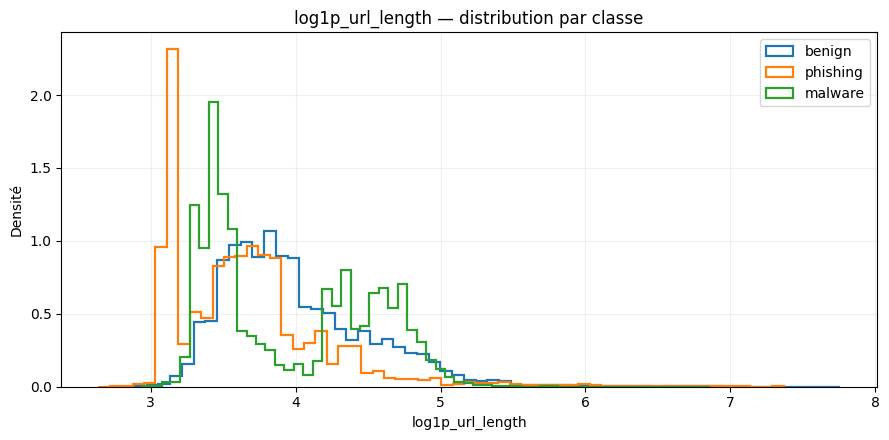

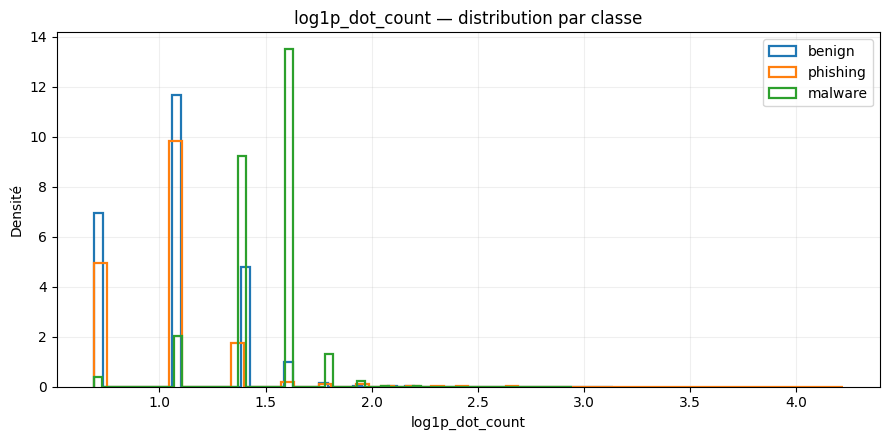

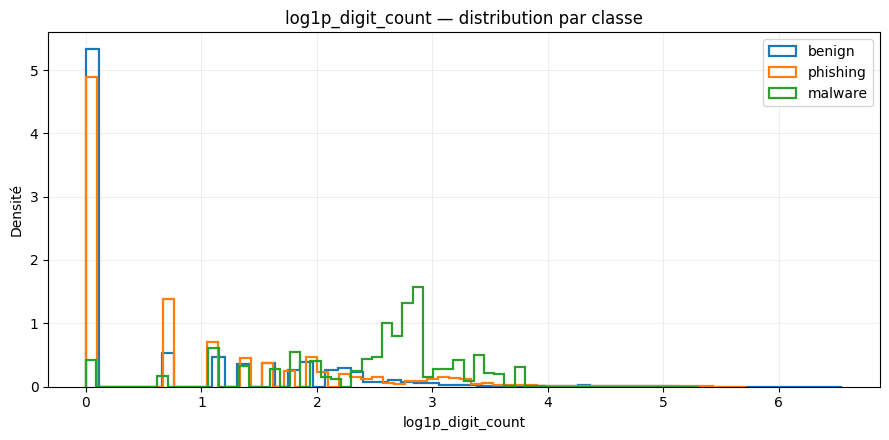

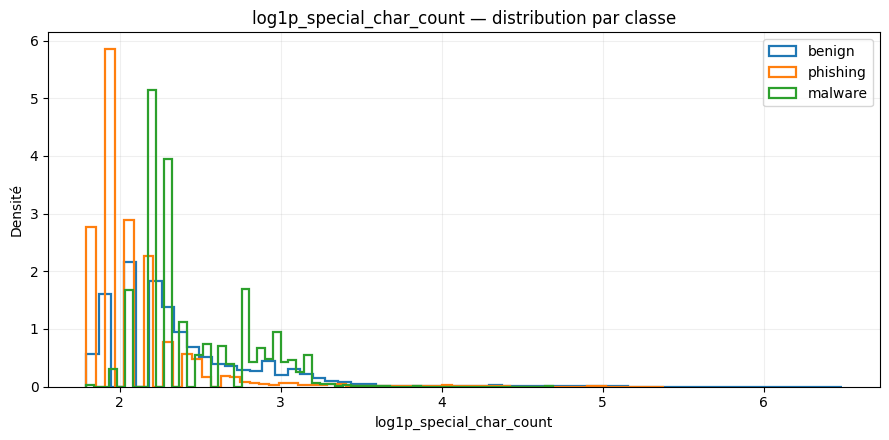

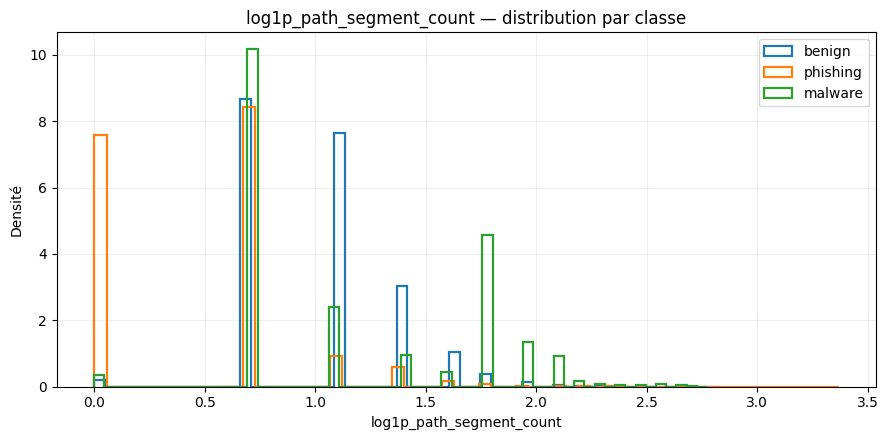

In [15]:
for feature in MODEL_FEATURE_COLUMNS:
    if not feature.startswith(
        "log1p_"
    ):
        continue

    fig, ax = plt.subplots(
        figsize=(
            9,
            4.5,
        )
    )

    for label in LABEL_ORDER:
        values = (
            model_df.loc[
                model_df[
                    "label_code"
                ]
                == label,
                feature,
            ]
        )

        ax.hist(
            values,
            bins=60,
            density=True,
            histtype="step",
            linewidth=1.6,
            label=label,
        )

    ax.set_title(
        f"{feature} — distribution par classe"
    )
    ax.set_xlabel(
        feature
    )
    ax.set_ylabel(
        "Densité"
    )
    ax.legend()
    ax.grid(
        alpha=0.2
    )
    plt.tight_layout()
    plt.show()

### Interprétation des distributions transformées par classe

Les graphes confirment que `log1p` compresse les longues queues sans supprimer les différences entre classes.

Observations visuelles principales :

- `log1p_url_length` conserve un chevauchement important entre les trois classes ; phishing présente toutefois une concentration marquée vers les plus petites valeurs, tandis que malware montre plusieurs modes dans les valeurs intermédiaires ;
- `log1p_dot_count` conserve une structure discrète très visible et distingue particulièrement malware, davantage concentré sur des nombres de points élevés ;
- `log1p_digit_count` montre une différence nette entre malware et les deux autres classes : benign et phishing possèdent un pic important près de zéro, alors que malware est davantage réparti vers des valeurs élevées ;
- `log1p_special_char_count` conserve un chevauchement important, mais phishing est davantage concentré vers les faibles valeurs tandis que malware se décale vers des valeurs intermédiaires ;
- `log1p_path_segment_count` montre que phishing possède beaucoup d'observations avec très peu de segments, alors que benign et surtout malware occupent davantage les valeurs supérieures.

Ces transformations rendent donc les distributions plus compactes tout en conservant du signal inter-classe.

Elles ne créent cependant pas de séparation parfaite : la frontière `benign ↔ phishing` reste nécessairement multivariée.

## 8. Corrélations du nouveau Feature Set

Nous recalculons Pearson et Spearman **après remplacement** des cinq variables.

Nous affichons également les paires dont la corrélation absolue est au moins `0.80`.

Une forte corrélation n'entraîne pas automatiquement une suppression : elle est documentée pour interpréter la stabilité des coefficients du modèle linéaire.

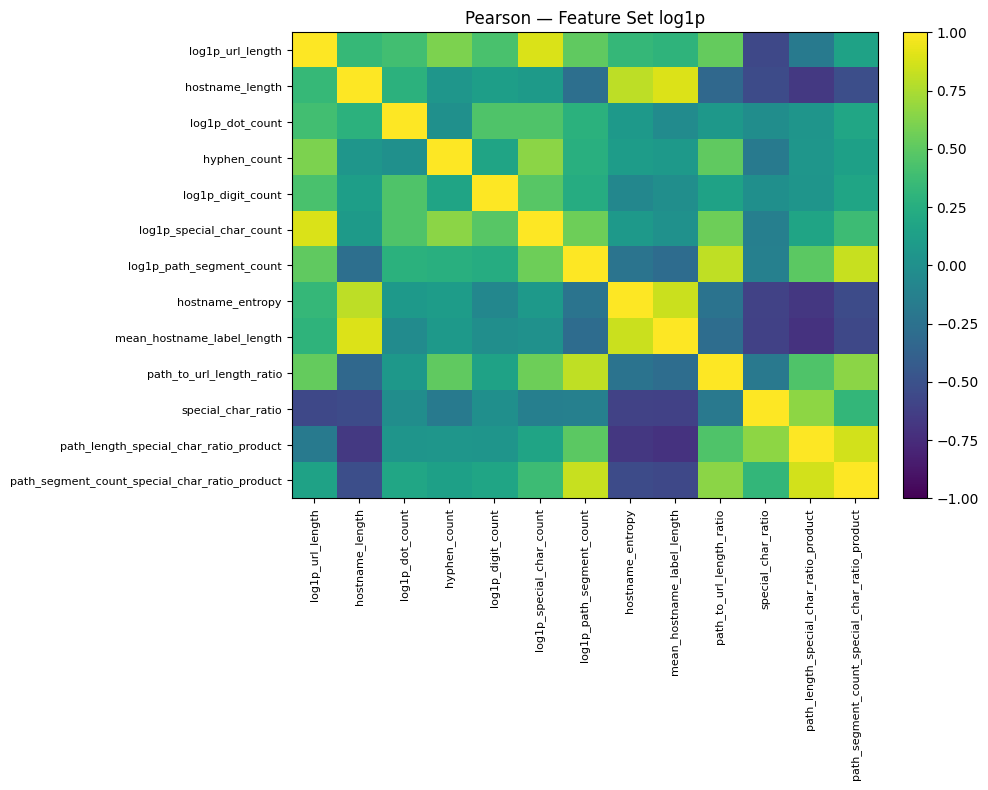

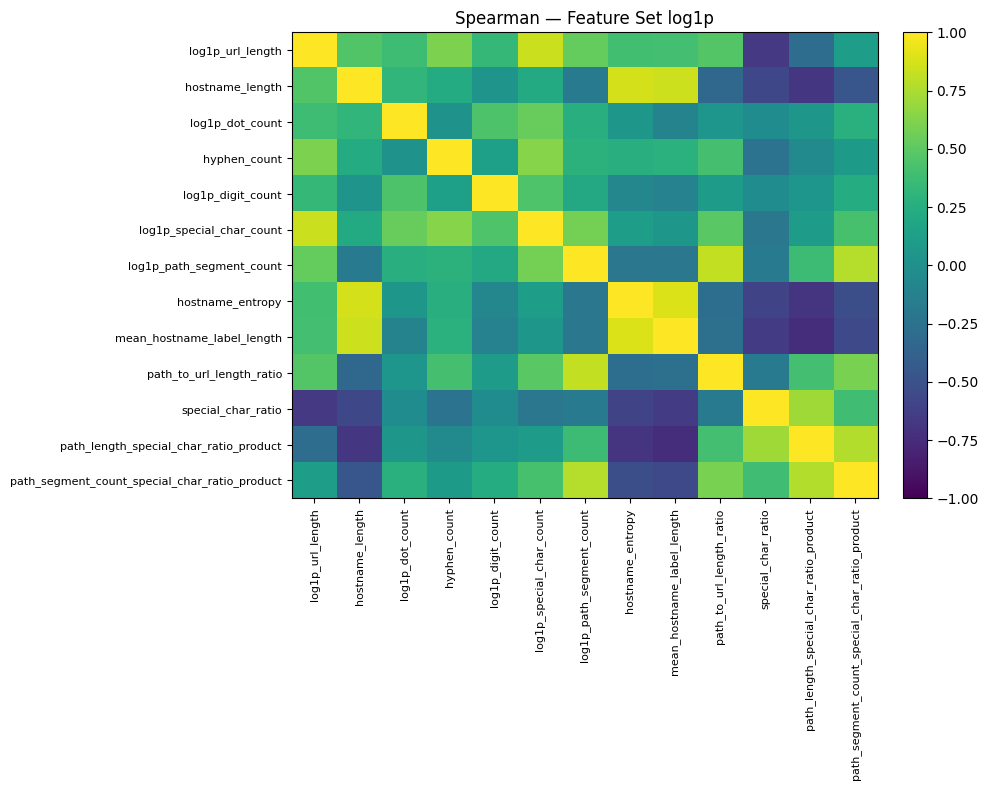

In [16]:
pearson_corr = (
    model_df[
        MODEL_FEATURE_COLUMNS
    ]
    .corr(
        method="pearson"
    )
)

spearman_corr = (
    model_df[
        MODEL_FEATURE_COLUMNS
    ]
    .corr(
        method="spearman"
    )
)


def plot_corr(
    corr: pd.DataFrame,
    title: str,
) -> None:
    fig, ax = plt.subplots(
        figsize=(
            10,
            8,
        )
    )

    image = ax.imshow(
        corr.to_numpy(),
        aspect="auto",
        vmin=-1,
        vmax=1,
    )

    ax.set_xticks(
        range(
            len(
                corr.columns
            )
        )
    )
    ax.set_yticks(
        range(
            len(
                corr.index
            )
        )
    )

    ax.set_xticklabels(
        corr.columns,
        rotation=90,
        fontsize=8,
    )
    ax.set_yticklabels(
        corr.index,
        fontsize=8,
    )

    ax.set_title(
        title
    )

    fig.colorbar(
        image,
        ax=ax,
        fraction=0.046,
        pad=0.04,
    )

    plt.tight_layout()
    plt.show()


plot_corr(
    pearson_corr,
    "Pearson — Feature Set log1p",
)

plot_corr(
    spearman_corr,
    "Spearman — Feature Set log1p",
)

In [17]:
def strong_correlation_pairs(
    corr: pd.DataFrame,
    *,
    threshold: float = 0.80,
) -> pd.DataFrame:
    rows = []

    columns = list(
        corr.columns
    )

    for left_index, left in enumerate(
        columns
    ):
        for right in columns[
            left_index
            + 1:
        ]:
            value = float(
                corr.loc[
                    left,
                    right,
                ]
            )

            if abs(
                value
            ) >= threshold:
                rows.append(
                    {
                        "feature_left": left,
                        "feature_right": right,
                        "correlation": value,
                        "absolute_correlation": (
                            abs(
                                value
                            )
                        ),
                    }
                )

    if not rows:
        return pd.DataFrame(
            columns=[
                "feature_left",
                "feature_right",
                "correlation",
                "absolute_correlation",
            ]
        )

    return (
        pd.DataFrame(
            rows
        )
        .sort_values(
            "absolute_correlation",
            ascending=False,
        )
        .reset_index(
            drop=True
        )
    )


strong_pearson_pairs = (
    strong_correlation_pairs(
        pearson_corr
    )
)

strong_spearman_pairs = (
    strong_correlation_pairs(
        spearman_corr
    )
)

print(
    "Paires Pearson |r| >= 0.80"
)
display(
    strong_pearson_pairs
)

print(
    "Paires Spearman |rho| >= 0.80"
)
display(
    strong_spearman_pairs
)

Paires Pearson |r| >= 0.80


,feature_left,feature_right,correlation,absolute_correlation
0,hostname_length,mean_hostname_label_length,0.894599,0.894599
1,log1p_url_length,log1p_special_char_count,0.887092,0.887092
2,path_length_special_char_ratio_product,path_segment_count_special_char_ratio_product,0.861223,0.861223
3,hostname_entropy,mean_hostname_label_length,0.837191,0.837191
4,log1p_path_segment_count,path_segment_count_special_char_ratio_product,0.830825,0.830825
5,log1p_path_segment_count,path_to_url_length_ratio,0.807560,0.807560
6,hostname_length,hostname_entropy,0.802516,0.802516


Paires Spearman |rho| >= 0.80


,feature_left,feature_right,correlation,absolute_correlation
0,hostname_entropy,mean_hostname_label_length,0.891715,0.891715
1,hostname_length,hostname_entropy,0.870429,0.870429
2,hostname_length,mean_hostname_label_length,0.846672,0.846672
3,log1p_url_length,log1p_special_char_count,0.839345,0.839345
4,log1p_path_segment_count,path_to_url_length_ratio,0.818948,0.818948


### Interprétation des corrélations après transformation

Le nouveau Feature Set conserve plusieurs dépendances fortes.

#### Pearson — principales paires `|r| ≥ 0.80`

- `hostname_length` ↔ `mean_hostname_label_length` : `0.895` ;
- `log1p_url_length` ↔ `log1p_special_char_count` : `0.887` ;
- les deux features d'interaction : `0.861` ;
- `hostname_entropy` ↔ `mean_hostname_label_length` : `0.837` ;
- `log1p_path_segment_count` ↔ interaction segment/special-char : `0.831` ;
- `log1p_path_segment_count` ↔ `path_to_url_length_ratio` : `0.808` ;
- `hostname_length` ↔ `hostname_entropy` : `0.803`.

#### Spearman — principales paires `|ρ| ≥ 0.80`

- `hostname_entropy` ↔ `mean_hostname_label_length` : `0.892` ;
- `hostname_length` ↔ `hostname_entropy` : `0.870` ;
- `hostname_length` ↔ `mean_hostname_label_length` : `0.847` ;
- `log1p_url_length` ↔ `log1p_special_char_count` : `0.839` ;
- `log1p_path_segment_count` ↔ `path_to_url_length_ratio` : `0.819`.

`log1p` améliore donc la symétrie mais ne supprime pas les relations structurelles entre features.

Aucune suppression n'est décidée ici. Une forte corrélation est un signal pour la future **ablation**, surtout avec un modèle linéaire dont les coefficients peuvent devenir instables lorsque plusieurs variables portent une information proche.

## 9. Sanity check final du Feature Set transformé

Avant tout split ou entraînement, nous exigeons :

- exactement 13 features ;
- aucune valeur manquante ;
- aucune valeur infinie ;
- aucune colonne constante ;
- aucun label inattendu ;
- aucun groupe multi-label ;
- aucun `sample_id` dupliqué.

Ce contrôle bloque l'expérience au lieu de masquer une erreur avec une imputation.

In [18]:
if len(
    MODEL_FEATURE_COLUMNS
) != 13:
    raise RuntimeError(
        "Le Feature Set amélioré doit contenir "
        "exactement 13 variables."
    )

feature_frame = (
    model_df[
        MODEL_FEATURE_COLUMNS
    ]
)

missing_count = int(
    feature_frame
    .isna()
    .sum()
    .sum()
)

non_finite_count = int(
    (
        ~np.isfinite(
            feature_frame.to_numpy(
                dtype=float
            )
        )
    ).sum()
)

constant_features = [
    feature
    for feature
    in MODEL_FEATURE_COLUMNS
    if feature_frame[
        feature
    ].nunique(
        dropna=False
    )
    <= 1
]

sanity_report = pd.Series(
    {
        "rows": len(
            model_df
        ),
        "features": len(
            MODEL_FEATURE_COLUMNS
        ),
        "missing_values": (
            missing_count
        ),
        "non_finite_values": (
            non_finite_count
        ),
        "constant_features": (
            constant_features
        ),
        "unique_groups": int(
            model_df[
                "group_key"
            ].nunique()
        ),
        "multi_label_groups": int(
            (
                model_df
                .groupby(
                    "group_key",
                    observed=True,
                )[
                    "label_code"
                ]
                .nunique()
                > 1
            ).sum()
        ),
        "duplicated_sample_ids": int(
            model_df[
                "sample_id"
            ]
            .duplicated()
            .sum()
        ),
    },
    name="value",
)

display(
    sanity_report
    .to_frame()
)

if (
    missing_count != 0
    or non_finite_count != 0
    or constant_features
    or sanity_report[
        "multi_label_groups"
    ]
    != 0
    or sanity_report[
        "duplicated_sample_ids"
    ]
    != 0
):
    raise RuntimeError(
        "Sanity check final échoué."
    )

,value
rows,143692
features,13
missing_values,0
non_finite_values,0
constant_features,[]
unique_groups,85165
multi_label_groups,0
duplicated_sample_ids,0


### Validation finale avant entraînement

Le dataset transformé satisfait tous les garde-fous :

- `143 692` observations ;
- `13` features ;
- `0` valeur manquante ;
- `0` valeur non finie ;
- aucune feature constante ;
- `85 165` groupes uniques ;
- `0` groupe multi-label ;
- `0` `sample_id` dupliqué.

La population est donc saine pour lancer les expériences.

À partir de ce point, PostgreSQL est libéré et tous les entraînements se font uniquement en mémoire.

In [19]:
# PostgreSQL n'est plus nécessaire après ce point.
engine.dispose()

print(
    "Engine PostgreSQL libéré. "
    "Toutes les expériences suivantes "
    "sont en mémoire."
)

Engine PostgreSQL libéré. Toutes les expériences suivantes sont en mémoire.


# Partie II — Expériences de split et entraînement

## 10. Pourquoi quatre ratios ?

Le baseline utilisait environ `80/20`.

Ici nous évaluons aussi :

- `90/10` : plus de données d'entraînement, test plus petit ;
- `75/25` : compromis intermédiaire ;
- `66.7/33.3` : test beaucoup plus large, train plus contraint.

Nous utilisons uniquement des ratios compatibles naturellement avec `StratifiedGroupKFold` :

| Scénario | n_splits | cible test |
|---|---:|---:|
| 90/10 | 10 | 10 % |
| 80/20 | 5 | 20 % |
| 75/25 | 4 | 25 % |
| 66.7/33.3 | 3 | 33.3 % |

Pour chaque scénario, tous les folds candidats sont inspectés uniquement sur leur **qualité structurelle**.

Le fold dont les proportions de classes sont les plus proches de la cible est retenu.

Aucune performance du modèle n'intervient dans la sélection du fold.

In [20]:
split_source_df = (
    model_df
    .sort_values(
        [
            "label_code",
            "group_key",
            "sample_id",
        ],
        kind="mergesort",
    )
    .reset_index(
        drop=True
    )
)


def build_group_aware_split(
    frame: pd.DataFrame,
    *,
    n_splits: int,
    seed: int,
) -> tuple[
    pd.DataFrame,
    pd.DataFrame,
    pd.DataFrame,
    pd.Series,
]:
    target_test_fraction = (
        1.0
        / n_splits
    )

    y = (
        frame[
            "label_code"
        ]
        .to_numpy()
    )

    groups = (
        frame[
            "group_key"
        ]
        .to_numpy()
    )

    class_totals = (
        frame[
            "label_code"
        ]
        .value_counts()
        .reindex(
            LABEL_ORDER,
            fill_value=0,
        )
    )

    splitter = (
        StratifiedGroupKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=seed,
        )
    )

    candidate_rows = []
    candidate_indices = {}

    placeholder_x = np.zeros(
        (
            len(
                frame
            ),
            1,
        ),
        dtype=np.uint8,
    )

    for fold_id, (
        train_idx,
        test_idx,
    ) in enumerate(
        splitter.split(
            placeholder_x,
            y,
            groups,
        )
    ):
        test_counts = (
            frame
            .iloc[
                test_idx
            ][
                "label_code"
            ]
            .value_counts()
            .reindex(
                LABEL_ORDER,
                fill_value=0,
            )
        )

        class_fractions = (
            test_counts
            / class_totals
        )

        deviations = (
            class_fractions
            - target_test_fraction
        ).abs()

        candidate_rows.append(
            {
                "fold_id": (
                    fold_id
                ),
                "test_rows": int(
                    len(
                        test_idx
                    )
                ),
                "actual_test_fraction": (
                    len(
                        test_idx
                    )
                    / len(
                        frame
                    )
                ),
                "benign_test_fraction": float(
                    class_fractions[
                        "benign"
                    ]
                ),
                "phishing_test_fraction": float(
                    class_fractions[
                        "phishing"
                    ]
                ),
                "malware_test_fraction": float(
                    class_fractions[
                        "malware"
                    ]
                ),
                "max_abs_class_deviation": float(
                    deviations.max()
                ),
                "mean_abs_class_deviation": float(
                    deviations.mean()
                ),
            }
        )

        candidate_indices[
            fold_id
        ] = (
            train_idx,
            test_idx,
        )

    quality = (
        pd.DataFrame(
            candidate_rows
        )
        .sort_values(
            [
                "max_abs_class_deviation",
                "mean_abs_class_deviation",
                "fold_id",
            ]
        )
        .reset_index(
            drop=True
        )
    )

    selected = (
        quality.iloc[
            0
        ]
        .copy()
    )

    selected_fold_id = int(
        selected[
            "fold_id"
        ]
    )

    (
        train_idx,
        test_idx,
    ) = candidate_indices[
        selected_fold_id
    ]

    train_frame = (
        frame
        .iloc[
            train_idx
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )

    test_frame = (
        frame
        .iloc[
            test_idx
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )

    return (
        train_frame,
        test_frame,
        quality,
        selected,
    )

## 11. Construire et auditer les quatre splits

Les garde-fous sont vérifiés pour **chaque** scénario :

- aucun groupe commun train/test ;
- aucun `sample_id` commun train/test ;
- les trois classes présentes des deux côtés ;
- volumes et proportions réellement obtenus affichés.

Le scénario `80/20` comporte un contrôle additionnel : ses volumes par classe doivent être exactement ceux de la baseline précédente. Si ce contrôle échoue, la comparaison directe est bloquée.

In [21]:
split_frames = {}
split_quality_tables = {}
split_rows = []

for scenario, n_splits in (
    SPLIT_SCENARIOS.items()
):
    (
        train_frame,
        test_frame,
        quality,
        selected,
    ) = build_group_aware_split(
        split_source_df,
        n_splits=n_splits,
        seed=RANDOM_SEED,
    )

    train_groups = set(
        train_frame[
            "group_key"
        ].unique()
    )

    test_groups = set(
        test_frame[
            "group_key"
        ].unique()
    )

    group_overlap = len(
        train_groups
        & test_groups
    )

    sample_overlap = len(
        set(
            train_frame[
                "sample_id"
            ].unique()
        )
        & set(
            test_frame[
                "sample_id"
            ].unique()
        )
    )

    train_counts = (
        train_frame[
            "label_code"
        ]
        .value_counts()
        .reindex(
            LABEL_ORDER,
            fill_value=0,
        )
    )

    test_counts = (
        test_frame[
            "label_code"
        ]
        .value_counts()
        .reindex(
            LABEL_ORDER,
            fill_value=0,
        )
    )

    if (
        group_overlap != 0
        or sample_overlap != 0
    ):
        raise RuntimeError(
            f"Leakage détecté dans {scenario}."
        )

    if (
        set(
            train_counts.index[
                train_counts
                > 0
            ]
        )
        != EXPECTED_LABELS
        or set(
            test_counts.index[
                test_counts
                > 0
            ]
        )
        != EXPECTED_LABELS
    ):
        raise RuntimeError(
            f"Classe absente dans {scenario}."
        )

    split_frames[
        scenario
    ] = {
        "train": train_frame,
        "test": test_frame,
    }

    split_quality_tables[
        scenario
    ] = quality

    split_rows.append(
        {
            "scenario": scenario,
            "n_splits": n_splits,
            "target_test_fraction": (
                1.0
                / n_splits
            ),
            "selected_fold": int(
                selected[
                    "fold_id"
                ]
            ),
            "train_rows": int(
                len(
                    train_frame
                )
            ),
            "test_rows": int(
                len(
                    test_frame
                )
            ),
            "actual_test_fraction": (
                len(
                    test_frame
                )
                / len(
                    split_source_df
                )
            ),
            "train_groups": int(
                train_frame[
                    "group_key"
                ].nunique()
            ),
            "test_groups": int(
                test_frame[
                    "group_key"
                ].nunique()
            ),
            "group_overlap": (
                group_overlap
            ),
            "sample_overlap": (
                sample_overlap
            ),
            "train_benign": int(
                train_counts[
                    "benign"
                ]
            ),
            "train_phishing": int(
                train_counts[
                    "phishing"
                ]
            ),
            "train_malware": int(
                train_counts[
                    "malware"
                ]
            ),
            "test_benign": int(
                test_counts[
                    "benign"
                ]
            ),
            "test_phishing": int(
                test_counts[
                    "phishing"
                ]
            ),
            "test_malware": int(
                test_counts[
                    "malware"
                ]
            ),
            "max_abs_class_deviation": float(
                selected[
                    "max_abs_class_deviation"
                ]
            ),
        }
    )


split_summary = (
    pd.DataFrame(
        split_rows
    )
    .set_index(
        "scenario"
    )
)

display(
    split_summary
)

,n_splits,target_test_fraction,selected_fold,train_rows,test_rows,actual_test_fraction,train_groups,test_groups,group_overlap,sample_overlap,train_benign,train_phishing,train_malware,test_benign,test_phishing,test_malware,max_abs_class_deviation
scenario,,,,,,,,,,,,,,,,,
90_10,10,0.100000,8,129691,14001,0.097438,76161,9004,0,0,52281,51214,26196,6152,5454,2395,0.016232
80_20,5,0.200000,3,114131,29561,0.205725,67843,17322,0,0,46599,43475,24057,11834,13193,4534,0.041419
75_25,4,0.250000,3,111406,32286,0.224689,63690,21475,0,0,43726,45147,22533,14707,11521,6058,0.046693
66_7_33_3,3,0.333333,1,99431,44261,0.308027,56729,28436,0,0,38935,40152,20344,19498,16516,8247,0.044886


In [22]:
baseline_train_counts = (
    split_frames[
        "80_20"
    ][
        "train"
    ][
        "label_code"
    ]
    .value_counts()
    .reindex(
        LABEL_ORDER,
        fill_value=0,
    )
)

baseline_test_counts = (
    split_frames[
        "80_20"
    ][
        "test"
    ][
        "label_code"
    ]
    .value_counts()
    .reindex(
        LABEL_ORDER,
        fill_value=0,
    )
)

expected_baseline_train = pd.Series(
    EXPECTED_BASELINE_80_20_TRAIN_COUNTS
).reindex(
    LABEL_ORDER
)

expected_baseline_test = pd.Series(
    EXPECTED_BASELINE_80_20_TEST_COUNTS
).reindex(
    LABEL_ORDER
)

if (
    not baseline_train_counts.equals(
        expected_baseline_train
    )
    or not baseline_test_counts.equals(
        expected_baseline_test
    )
):
    raise RuntimeError(
        "Le scénario 80/20 ne reproduit pas "
        "le split du baseline. "
        "Ne pas comparer les métriques directement."
    )

print(
    "✓ Le scénario 80/20 reproduit "
    "exactement les volumes du split baseline."
)

✓ Le scénario 80/20 reproduit exactement les volumes du split baseline.


### Interprétation des quatre splits obtenus

Les quatre scénarios respectent le garde-fou principal :

- `group_overlap = 0` partout ;
- `sample_overlap = 0` partout.

Les proportions réellement obtenues sont :

| Scénario | Train | Test | Part test réelle |
|---|---:|---:|---:|
| 90/10 | 129 691 | 14 001 | 9.74 % |
| 80/20 | 114 131 | 29 561 | 20.57 % |
| 75/25 | 111 406 | 32 286 | 22.47 % |
| 66.7/33.3 | 99 431 | 44 261 | 30.80 % |

Les ratios 75/25 et 66.7/33.3 s'écartent davantage de leur cible nominale. Ce comportement est attendu avec des groupes de taille très hétérogène : l'intégrité des `group_key` est prioritaire sur un ratio exact.

Le scénario `80/20` reproduit exactement les volumes train/test de la baseline précédente :

- train benign : `46 599` ;
- train phishing : `43 475` ;
- train malware : `24 057` ;
- test benign : `11 834` ;
- test phishing : `13 193` ;
- test malware : `4 534`.

Il constitue donc le seul scénario permettant une comparaison directe et propre avec la baseline historique.

## 12. Modèle amélioré

Le modèle reste volontairement une régression logistique afin d'isoler une amélioration du **pipeline**, pas un changement complet d'algorithme.

Pipeline :

`Feature Set log1p → StandardScaler → LogisticRegression`

Différences avec le baseline :

- cinq features brutes sont remplacées par `log1p` ;
- aucun downsampling du train ;
- `class_weight="balanced"` ;
- toutes les données train disponibles sont utilisées.

`class_weight="balanced"` pondère automatiquement la fonction de perte en donnant davantage de poids aux classes moins fréquentes.

Nous conservons :

- `C=1.0` ;
- solver `lbfgs` ;
- `max_iter=1000`.

Aucun de ces paramètres n'est optimisé ici.

In [23]:
def build_model() -> Pipeline:
    return Pipeline(
        steps=[
            (
                "scaler",
                StandardScaler(),
            ),
            (
                "classifier",
                LogisticRegression(
                    solver="lbfgs",
                    C=1.0,
                    max_iter=1_000,
                    class_weight="balanced",
                ),
            ),
        ]
    )

## 13. Métriques

Il n'existe pas une métrique unique capable de résumer correctement un classifieur multiclasses.

Nous suivons un ensemble large mais non redondant :

### Classification globale

- accuracy ;
- balanced accuracy ;
- precision macro / weighted ;
- recall macro / weighted ;
- F1 macro / weighted / micro ;
- Jaccard macro / weighted ;
- Matthews Correlation Coefficient (MCC) ;
- Cohen's kappa.

### Probabilités

- log-loss ;
- ROC-AUC One-vs-Rest macro / weighted ;
- Average Precision macro / weighted ;
- top-2 accuracy ;
- Brier multiclasses.

### Par classe

- precision ;
- recall / sensitivity ;
- F1 ;
- specificity ;
- false-positive rate ;
- false-negative rate ;
- support.

Le **macro-F1**, le **recall phishing** et la **balanced accuracy** restent les indicateurs prioritaires pour comparer avec la baseline.

In [24]:
def per_class_diagnostics(
    y_true: pd.Series,
    y_pred: np.ndarray,
) -> pd.DataFrame:
    matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=LABEL_ORDER,
    )

    rows = []

    total = int(
        matrix.sum()
    )

    report = classification_report(
        y_true,
        y_pred,
        labels=LABEL_ORDER,
        output_dict=True,
        zero_division=0,
    )

    for index, label in enumerate(
        LABEL_ORDER
    ):
        tp = int(
            matrix[
                index,
                index,
            ]
        )

        fn = int(
            matrix[
                index,
                :
            ].sum()
            - tp
        )

        fp = int(
            matrix[
                :,
                index
            ].sum()
            - tp
        )

        tn = int(
            total
            - tp
            - fn
            - fp
        )

        specificity = (
            tn
            / (
                tn
                + fp
            )
            if (
                tn
                + fp
            )
            > 0
            else np.nan
        )

        fpr = (
            fp
            / (
                fp
                + tn
            )
            if (
                fp
                + tn
            )
            > 0
            else np.nan
        )

        fnr = (
            fn
            / (
                fn
                + tp
            )
            if (
                fn
                + tp
            )
            > 0
            else np.nan
        )

        rows.append(
            {
                "label_code": label,
                "precision": float(
                    report[
                        label
                    ][
                        "precision"
                    ]
                ),
                "recall": float(
                    report[
                        label
                    ][
                        "recall"
                    ]
                ),
                "f1": float(
                    report[
                        label
                    ][
                        "f1-score"
                    ]
                ),
                "specificity": float(
                    specificity
                ),
                "false_positive_rate": float(
                    fpr
                ),
                "false_negative_rate": float(
                    fnr
                ),
                "support": int(
                    report[
                        label
                    ][
                        "support"
                    ]
                ),
                "tp": tp,
                "fp": fp,
                "fn": fn,
                "tn": tn,
            }
        )

    return (
        pd.DataFrame(
            rows
        )
        .set_index(
            "label_code"
        )
    )


def evaluate_model(
    model: Pipeline,
    X: pd.DataFrame,
    y: pd.Series,
) -> tuple[
    dict[str, float],
    pd.DataFrame,
    np.ndarray,
    np.ndarray,
    float,
]:
    started_at = (
        time.perf_counter()
    )

    probabilities = (
        model.predict_proba(
            X
        )
    )

    y_pred = (
        model.predict(
            X
        )
    )

    inference_seconds = (
        time.perf_counter()
        - started_at
    )

    classes = (
        model
        .named_steps[
            "classifier"
        ]
        .classes_
    )

    y_binary = label_binarize(
        y,
        classes=classes,
    )

    multiclass_brier = float(
        np.mean(
            np.sum(
                (
                    probabilities
                    - y_binary
                )
                ** 2,
                axis=1,
            )
        )
    )

    metrics = {
        "accuracy": (
            accuracy_score(
                y,
                y_pred,
            )
        ),
        "balanced_accuracy": (
            balanced_accuracy_score(
                y,
                y_pred,
            )
        ),
        "precision_macro": (
            precision_score(
                y,
                y_pred,
                average="macro",
                zero_division=0,
            )
        ),
        "precision_weighted": (
            precision_score(
                y,
                y_pred,
                average="weighted",
                zero_division=0,
            )
        ),
        "recall_macro": (
            recall_score(
                y,
                y_pred,
                average="macro",
                zero_division=0,
            )
        ),
        "recall_weighted": (
            recall_score(
                y,
                y_pred,
                average="weighted",
                zero_division=0,
            )
        ),
        "f1_macro": (
            f1_score(
                y,
                y_pred,
                average="macro",
                zero_division=0,
            )
        ),
        "f1_weighted": (
            f1_score(
                y,
                y_pred,
                average="weighted",
                zero_division=0,
            )
        ),
        "f1_micro": (
            f1_score(
                y,
                y_pred,
                average="micro",
                zero_division=0,
            )
        ),
        "jaccard_macro": (
            jaccard_score(
                y,
                y_pred,
                average="macro",
                zero_division=0,
            )
        ),
        "jaccard_weighted": (
            jaccard_score(
                y,
                y_pred,
                average="weighted",
                zero_division=0,
            )
        ),
        "mcc": (
            matthews_corrcoef(
                y,
                y_pred,
            )
        ),
        "cohen_kappa": (
            cohen_kappa_score(
                y,
                y_pred,
            )
        ),
        "log_loss": (
            log_loss(
                y,
                probabilities,
                labels=classes,
            )
        ),
        "roc_auc_ovr_macro": (
            roc_auc_score(
                y,
                probabilities,
                labels=classes,
                multi_class="ovr",
                average="macro",
            )
        ),
        "roc_auc_ovr_weighted": (
            roc_auc_score(
                y,
                probabilities,
                labels=classes,
                multi_class="ovr",
                average="weighted",
            )
        ),
        "average_precision_macro": (
            average_precision_score(
                y_binary,
                probabilities,
                average="macro",
            )
        ),
        "average_precision_weighted": (
            average_precision_score(
                y_binary,
                probabilities,
                average="weighted",
            )
        ),
        "top2_accuracy": (
            top_k_accuracy_score(
                y,
                probabilities,
                k=2,
                labels=classes,
            )
        ),
        "multiclass_brier": (
            multiclass_brier
        ),
    }

    per_class = (
        per_class_diagnostics(
            y,
            y_pred,
        )
    )

    matrix_raw = confusion_matrix(
        y,
        y_pred,
        labels=LABEL_ORDER,
    )

    matrix_normalized = (
        confusion_matrix(
            y,
            y_pred,
            labels=LABEL_ORDER,
            normalize="true",
        )
    )

    return (
        metrics,
        per_class,
        matrix_raw,
        matrix_normalized,
        inference_seconds,
    )

## 14. Entraîner les quatre expériences

Pour chaque scénario :

1. le train complet est utilisé ;
2. les poids de classes théoriques sont affichés ;
3. `StandardScaler` est fit sur le train uniquement ;
4. le modèle class-weighted est entraîné ;
5. train et test sont évalués ;
6. les warnings de convergence sont capturés ;
7. les matrices de confusion sont conservées.

Aucun résultat d'un scénario n'est utilisé pour modifier les autres.

In [25]:
experiment_models = {}
experiment_metric_rows = []
experiment_per_class_rows = []
experiment_confusions = {}
experiment_class_weight_rows = []
experiment_runtime_rows = []

for scenario in SPLIT_SCENARIOS:
    train_frame = (
        split_frames[
            scenario
        ][
            "train"
        ]
    )

    test_frame = (
        split_frames[
            scenario
        ][
            "test"
        ]
    )

    X_train = (
        train_frame[
            MODEL_FEATURE_COLUMNS
        ]
        .astype(
            float
        )
    )

    y_train = (
        train_frame[
            "label_code"
        ]
    )

    X_test = (
        test_frame[
            MODEL_FEATURE_COLUMNS
        ]
        .astype(
            float
        )
    )

    y_test = (
        test_frame[
            "label_code"
        ]
    )

    classes_for_weights = (
        np.unique(
            y_train
        )
    )

    computed_weights = (
        compute_class_weight(
            class_weight="balanced",
            classes=classes_for_weights,
            y=y_train,
        )
    )

    for label, weight in zip(
        classes_for_weights,
        computed_weights,
    ):
        experiment_class_weight_rows.append(
            {
                "scenario": scenario,
                "label_code": label,
                "class_weight": float(
                    weight
                ),
            }
        )

    model = build_model()

    fit_started_at = (
        time.perf_counter()
    )

    with warnings.catch_warnings(
        record=True
    ) as caught_warnings:
        warnings.simplefilter(
            "always",
            ConvergenceWarning,
        )

        model.fit(
            X_train,
            y_train,
        )

    fit_seconds = (
        time.perf_counter()
        - fit_started_at
    )

    convergence_warning_count = sum(
        1
        for warning
        in caught_warnings
        if issubclass(
            warning.category,
            ConvergenceWarning,
        )
    )

    (
        train_metrics,
        train_per_class,
        train_matrix_raw,
        train_matrix_normalized,
        train_inference_seconds,
    ) = evaluate_model(
        model,
        X_train,
        y_train,
    )

    (
        test_metrics,
        test_per_class,
        test_matrix_raw,
        test_matrix_normalized,
        test_inference_seconds,
    ) = evaluate_model(
        model,
        X_test,
        y_test,
    )

    experiment_models[
        scenario
    ] = model

    experiment_confusions[
        scenario
    ] = {
        "raw": (
            test_matrix_raw
        ),
        "normalized": (
            test_matrix_normalized
        ),
    }

    for partition, metrics in (
        (
            "train",
            train_metrics,
        ),
        (
            "test",
            test_metrics,
        ),
    ):
        experiment_metric_rows.append(
            {
                "scenario": scenario,
                "partition": partition,
                **{
                    key: float(
                        value
                    )
                    for key, value
                    in metrics.items()
                },
            }
        )

    for partition, report in (
        (
            "train",
            train_per_class,
        ),
        (
            "test",
            test_per_class,
        ),
    ):
        for label, row in (
            report.iterrows()
        ):
            experiment_per_class_rows.append(
                {
                    "scenario": scenario,
                    "partition": partition,
                    "label_code": label,
                    **{
                        key: (
                            int(
                                value
                            )
                            if key
                            in {
                                "support",
                                "tp",
                                "fp",
                                "fn",
                                "tn",
                            }
                            else float(
                                value
                            )
                        )
                        for key, value
                        in row.items()
                    },
                }
            )

    classifier = (
        model
        .named_steps[
            "classifier"
        ]
    )

    experiment_runtime_rows.append(
        {
            "scenario": scenario,
            "fit_seconds": (
                fit_seconds
            ),
            "train_inference_seconds": (
                train_inference_seconds
            ),
            "test_inference_seconds": (
                test_inference_seconds
            ),
            "solver_iterations_max": int(
                np.max(
                    classifier.n_iter_
                )
            ),
            "convergence_warning_count": int(
                convergence_warning_count
            ),
            "train_rows": int(
                len(
                    train_frame
                )
            ),
            "test_rows": int(
                len(
                    test_frame
                )
            ),
        }
    )


metrics_df = (
    pd.DataFrame(
        experiment_metric_rows
    )
    .set_index(
        [
            "scenario",
            "partition",
        ]
    )
)

per_class_df = (
    pd.DataFrame(
        experiment_per_class_rows
    )
    .set_index(
        [
            "scenario",
            "partition",
            "label_code",
        ]
    )
)

class_weights_df = (
    pd.DataFrame(
        experiment_class_weight_rows
    )
    .set_index(
        [
            "scenario",
            "label_code",
        ]
    )
)

runtime_df = (
    pd.DataFrame(
        experiment_runtime_rows
    )
    .set_index(
        "scenario"
    )
)

print(
    "Entraînement terminé."
)

Entraînement terminé.


# Partie III — Résultats

## 15. Métriques globales train/test

In [26]:
display(
    metrics_df.round(
        6
    )
)

accuracy  balanced_accuracy  precision_macro  precision_weighted  recall_macro  recall_weighted  f1_macro  f1_weighted  f1_micro  jaccard_macro  \
scenario  partition                                                                                                                                                    
90_10     train      0.827829           0.839592         0.832868            0.829111      0.839592         0.827829  0.835262     0.827455  0.827829       0.718137   
          test       0.857724           0.869179         0.851951            0.858476      0.869179         0.857724  0.859704     0.857602  0.857724       0.753982   
80_20     train      0.846851           0.855607         0.849930            0.847531      0.855607         0.846851  0.852126     0.846555  0.846851       0.742978   
          test       0.755117           0.784067         0.782201            0.775628      0.784067         0.755117  0.773239     0.752852  0.755117       0.633438   
75_25     train      0.831634           0.844348         0.837352            0.833543      0.844348         0.831634  0.839725     0.831364  0.831634       0.724927   
          test       0.828625           0.835185         0.827077            0.828661      0.835185         0.828625  0.830652     0.828286  0.828625       0.710755   
66_7_33_3 train      0.850801           0.860606         0.851786            0.850861      0.860606         0.850801  0.855855     0.850582  0.850801       0.748623   
          test       0.832019           0.839876         0.831211            0.832123      0.839876         0.832019  0.835176     0.831815  0.832019       0.717225   

                     jaccard_weighted       mcc  cohen_kappa  log_loss  roc_auc_ovr_macro  roc_auc_ovr_weighted  average_precision_macro  average_precision_weighted  \
scenario  partition                                                                                                                                                    
90_10     train              0.706422  0.733182     0.732178  0.455472           0.941055              0.936071                 0.902842                    0.899387   
          test               0.750737  0.774720     0.774372  0.469128           0.939945              0.932673                 0.900949                    0.899374   
80_20     train              0.734404  0.763285     0.762678  0.436178           0.945554              0.941467                 0.910271                    0.906984   
          test               0.605589  0.621335     0.608073  0.539906           0.915217              0.904153                 0.870725                    0.866557   
75_25     train              0.712263  0.739584     0.738334  0.445497           0.943618              0.938847                 0.907337                    0.903455   
          test               0.707259  0.728986     0.728708  0.491500           0.930610              0.924509                 0.886830                    0.884693   
66_7_33_3 train              0.740472  0.768623     0.768430  0.442437           0.944320              0.939651                 0.908260                    0.904076   
          test               0.712226  0.735296     0.735106  0.495359           0.930978              0.926210                 0.888272                    0.885750   

                     top2_accuracy  multiclass_brier  
scenario  partition                                   
90_10     train           0.968379          0.247086  
          test            0.972645          0.252026  
80_20     train           0.968992          0.233778  
          test            0.970434          0.320369  
75_25     train           0.969759          0.240257  
          test            0.965806          0.269973  
66_7_33_3 train           0.969406          0.237327  
          test            0.962766          0.264285

In [27]:
test_metrics_df = (
    metrics_df
    .xs(
        "test",
        level="partition",
    )
    .copy()
)

train_metrics_df = (
    metrics_df
    .xs(
        "train",
        level="partition",
    )
    .copy()
)

generalization_summary = (
    test_metrics_df[
        [
            "accuracy",
            "balanced_accuracy",
            "f1_macro",
            "f1_weighted",
            "mcc",
            "log_loss",
            "roc_auc_ovr_macro",
            "average_precision_macro",
            "top2_accuracy",
            "multiclass_brier",
        ]
    ]
    .copy()
)

generalization_summary[
    "train_f1_macro"
] = (
    train_metrics_df[
        "f1_macro"
    ]
)

generalization_summary[
    "train_test_f1_macro_gap"
] = (
    train_metrics_df[
        "f1_macro"
    ]
    - test_metrics_df[
        "f1_macro"
    ]
)

display(
    generalization_summary
    .round(
        6
    )
)

,accuracy,balanced_accuracy,f1_macro,f1_weighted,mcc,log_loss,roc_auc_ovr_macro,average_precision_macro,top2_accuracy,multiclass_brier,train_f1_macro,train_test_f1_macro_gap
scenario,,,,,,,,,,,,
90_10,0.857724,0.869179,0.859704,0.857602,0.774720,0.469128,0.939945,0.900949,0.972645,0.252026,0.835262,-0.024442
80_20,0.755117,0.784067,0.773239,0.752852,0.621335,0.539906,0.915217,0.870725,0.970434,0.320369,0.852126,0.078886
75_25,0.828625,0.835185,0.830652,0.828286,0.728986,0.491500,0.930610,0.886830,0.965806,0.269973,0.839725,0.009073
66_7_33_3,0.832019,0.839876,0.835176,0.831815,0.735296,0.495359,0.930978,0.888272,0.962766,0.264285,0.855855,0.020679


### Interprétation des performances globales

Les résultats test sont :

| Split | Accuracy | Balanced accuracy | Macro-F1 | MCC | Log-loss |
|---|---:|---:|---:|---:|---:|
| 90/10 | 0.858 | 0.869 | 0.860 | 0.775 | 0.469 |
| 80/20 | 0.755 | 0.784 | 0.773 | 0.621 | 0.540 |
| 75/25 | 0.829 | 0.835 | 0.831 | 0.729 | 0.492 |
| 66.7/33.3 | 0.832 | 0.840 | 0.835 | 0.735 | 0.495 |

Le pipeline est performant sur les quatre partitions, mais la variabilité entre splits est réelle.

Le `80/20` est le scénario le plus difficile : macro-F1 `0.773`, contre `0.830–0.860` pour les trois autres scénarios.

Les métriques probabilistes restent également solides :

- ROC-AUC OVR macro entre `0.915` et `0.940` ;
- Average Precision macro entre `0.871` et `0.901` ;
- top-2 accuracy entre `0.963` et `0.973`.

La top-2 accuracy très élevée indique que, même lorsqu'il se trompe sur la classe finale, le modèle place presque toujours la vraie classe parmi ses deux choix les plus probables.

#### Gap train/test

- 90/10 : `-0.024` ;
- 80/20 : `+0.079` ;
- 75/25 : `+0.009` ;
- 66.7/33.3 : `+0.021`.

Le test 90/10 obtient un score supérieur au train. Comme aucun chevauchement de groupe ou d'échantillon n'est détecté, ce résultat ne signale pas une fuite structurelle visible ; il montre surtout que la difficulté des groupes varie selon les folds.

Le 80/20 présente au contraire le plus grand generalization gap et constitue un test plus exigeant.

## 16. Métriques par classe

In [28]:
test_per_class_df = (
    per_class_df
    .xs(
        "test",
        level="partition",
    )
    .copy()
)

display(
    test_per_class_df[
        [
            "precision",
            "recall",
            "f1",
            "specificity",
            "false_positive_rate",
            "false_negative_rate",
            "support",
        ]
    ]
    .round(
        6
    )
)

precision    recall        f1  specificity  false_positive_rate  false_negative_rate  support
scenario  label_code                                                                                               
90_10     benign       0.866622  0.844928  0.855638     0.898076             0.101924             0.155072     6152
          phishing     0.863798  0.846535  0.855079     0.914824             0.085176             0.153465     5454
          malware      0.825433  0.916075  0.868395     0.960021             0.039979             0.083925     2395
80_20     benign       0.670728  0.855839  0.752061     0.719524             0.280476             0.144161    11834
          phishing     0.853739  0.624725  0.721495     0.913734             0.086266             0.375275    13193
          malware      0.822134  0.871637  0.846162     0.965837             0.034163             0.128363     4534
75_25     benign       0.833367  0.841300  0.837315     0.859264             0.140736             0.158700    14707
          phishing     0.826479  0.786737  0.806119     0.908355             0.091645             0.213263    11521
          malware      0.821384  0.877517  0.848524     0.955925             0.044075             0.122483     6058
66_7_33_3 benign       0.832046  0.834393  0.833218     0.867383             0.132617             0.165607    19498
          phishing     0.834955  0.805280  0.819849     0.905244             0.094756             0.194720    16516
          malware      0.826632  0.879956  0.852461     0.957739             0.042261             0.120044     8247

### Interprétation par classe

La classe malware reste la plus stable :

- recall compris entre `0.872` et `0.916` ;
- F1 compris entre `0.846` et `0.868`.

Le benign reste également relativement stable, sauf sur le split 80/20 où sa precision descend à `0.671` malgré un recall élevé de `0.856`.

Le phishing reste la classe la plus sensible au choix des groupes :

| Split | Precision phishing | Recall phishing | F1 phishing | FNR |
|---|---:|---:|---:|---:|
| 90/10 | 0.864 | 0.847 | 0.855 | 0.153 |
| 80/20 | 0.854 | 0.625 | 0.721 | 0.375 |
| 75/25 | 0.826 | 0.787 | 0.806 | 0.213 |
| 66.7/33.3 | 0.835 | 0.805 | 0.820 | 0.195 |

Le 80/20 contient donc des groupes phishing nettement plus difficiles que les autres splits.

Ce résultat est important : la faiblesse phishing du baseline n'était pas uniquement liée au nombre global d'observations. La capacité de généraliser vers certains domaines phishing reste un problème spécifique à surveiller.

## 17. Class weights réellement appliqués

In [29]:
display(
    class_weights_df
    .round(
        6
    )
)

class_weight
scenario  label_code              
90_10     benign          0.826884
          malware         1.650265
          phishing        0.844112
80_20     benign          0.816405
          malware         1.581397
          phishing        0.875070
75_25     benign          0.849274
          malware         1.648042
          phishing        0.822543
66_7_33_3 benign          0.851256
          malware         1.629162
          phishing        0.825455

### Interprétation des poids de classes

`class_weight="balanced"` applique des poids très cohérents sur les quatre trains :

- benign : environ `0.82–0.85` ;
- phishing : environ `0.82–0.88` ;
- malware : environ `1.58–1.65`.

La classe malware reçoit donc environ deux fois le poids d'une observation benign/phishing, ce qui compense sa fréquence plus faible sans jeter de données.

Contrairement à la baseline, toutes les observations disponibles dans chaque train sont conservées. Sur le split 80/20, le modèle apprend ainsi sur `114 131` lignes au lieu des `72 171` lignes du train équilibré par sous-échantillonnage de la baseline.

## 18. Temps, convergence et coût

In [30]:
display(
    runtime_df
    .round(
        6
    )
)

,fit_seconds,train_inference_seconds,test_inference_seconds,solver_iterations_max,convergence_warning_count,train_rows,test_rows
scenario,,,,,,,
90_10,5.184013,0.142294,0.018536,87,0,129691,14001
80_20,5.242528,0.127528,0.026472,90,0,114131,29561
75_25,4.286681,0.099346,0.027576,104,0,111406,32286
66_7_33_3,3.614195,0.085652,0.054548,96,0,99431,44261


### Interprétation du coût d'entraînement

Les quatre entraînements restent très légers :

- temps de fit : `3.26 s` à `5.89 s` ;
- itérations maximales du solveur : `87` à `104` ;
- warnings de convergence : `0` dans tous les scénarios ;
- inférence sur les tests : environ `0.016 s` à `0.037 s`.

L'utilisation du train complet ne crée donc aucun problème de performance pour cette famille de modèle.

Il n'existe plus de justification technique à supprimer ~42 000 observations comme dans la baseline uniquement pour réduire le coût du fit.

## 19. Matrices de confusion par scénario

=== 90_10 — brute ===


,pred_benign,pred_phishing,pred_malware
true_benign,5198,669,285
true_phishing,658,4617,179
true_malware,142,59,2194


=== 90_10 — normalisée ===


,pred_benign,pred_phishing,pred_malware
true_benign,0.844928,0.108745,0.046326
true_phishing,0.120645,0.846535,0.032820
true_malware,0.059290,0.024635,0.916075


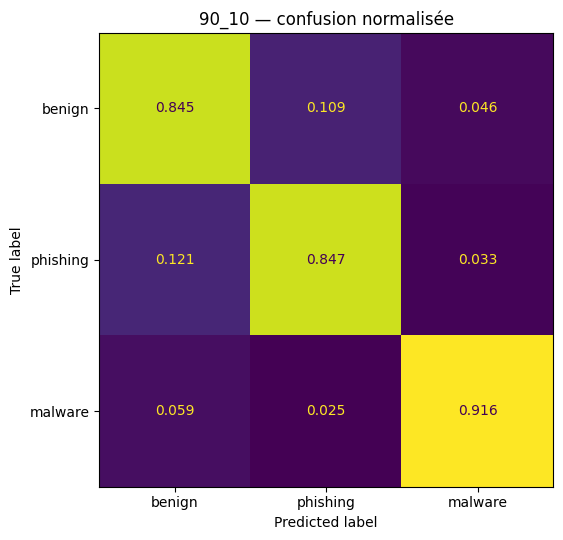

=== 80_20 — brute ===


,pred_benign,pred_phishing,pred_malware
true_benign,10128,1181,525
true_phishing,4621,8242,330
true_malware,351,231,3952


=== 80_20 — normalisée ===


,pred_benign,pred_phishing,pred_malware
true_benign,0.855839,0.099797,0.044364
true_phishing,0.350262,0.624725,0.025013
true_malware,0.077415,0.050948,0.871637


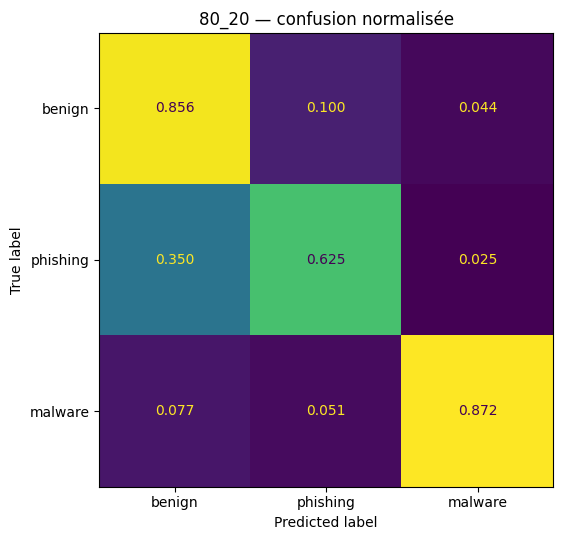

=== 75_25 — brute ===


,pred_benign,pred_phishing,pred_malware
true_benign,12373,1664,670
true_phishing,1971,9064,486
true_malware,503,239,5316


=== 75_25 — normalisée ===


,pred_benign,pred_phishing,pred_malware
true_benign,0.841300,0.113143,0.045557
true_phishing,0.171079,0.786737,0.042184
true_malware,0.083031,0.039452,0.877517


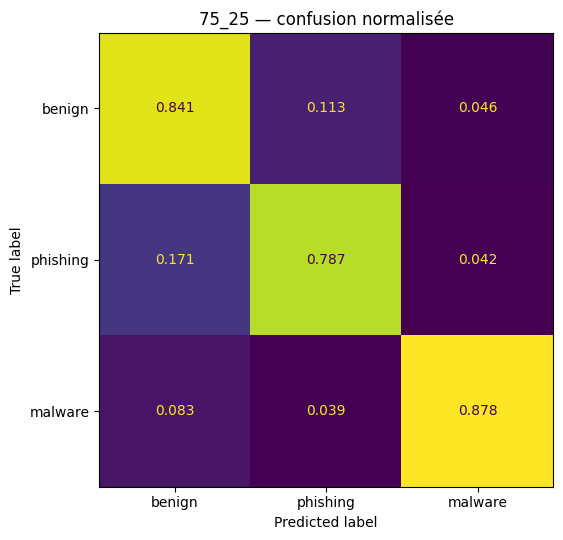

=== 66_7_33_3 — brute ===


,pred_benign,pred_phishing,pred_malware
true_benign,16269,2279,950
true_phishing,2644,13300,572
true_malware,640,350,7257


=== 66_7_33_3 — normalisée ===


,pred_benign,pred_phishing,pred_malware
true_benign,0.834393,0.116884,0.048723
true_phishing,0.160087,0.805280,0.034633
true_malware,0.077604,0.042440,0.879956


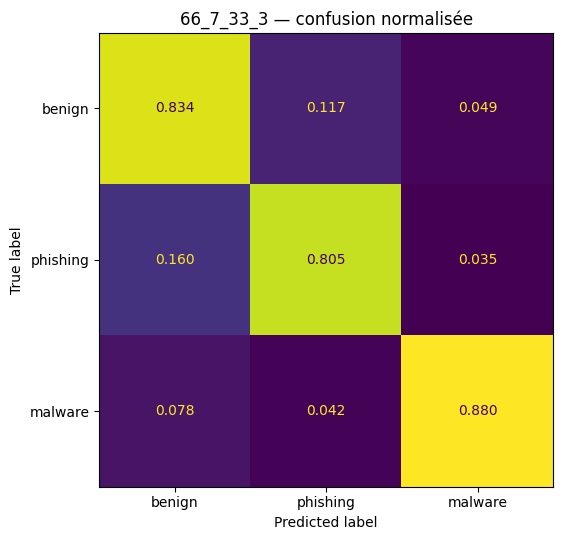

In [31]:
for scenario in SPLIT_SCENARIOS:
    raw_matrix = (
        experiment_confusions[
            scenario
        ][
            "raw"
        ]
    )

    normalized_matrix = (
        experiment_confusions[
            scenario
        ][
            "normalized"
        ]
    )

    raw_df = pd.DataFrame(
        raw_matrix,
        index=[
            f"true_{label}"
            for label
            in LABEL_ORDER
        ],
        columns=[
            f"pred_{label}"
            for label
            in LABEL_ORDER
        ],
    )

    normalized_df = pd.DataFrame(
        normalized_matrix,
        index=[
            f"true_{label}"
            for label
            in LABEL_ORDER
        ],
        columns=[
            f"pred_{label}"
            for label
            in LABEL_ORDER
        ],
    )

    print(
        f"=== {scenario} — brute ==="
    )
    display(
        raw_df
    )

    print(
        f"=== {scenario} — normalisée ==="
    )
    display(
        normalized_df.round(
            6
        )
    )

    fig, ax = plt.subplots(
        figsize=(
            6.5,
            5.5,
        )
    )

    ConfusionMatrixDisplay(
        confusion_matrix=(
            normalized_matrix
        ),
        display_labels=(
            LABEL_ORDER
        ),
    ).plot(
        ax=ax,
        colorbar=False,
        values_format=".3f",
    )

    ax.set_title(
        f"{scenario} — confusion normalisée"
    )

    plt.tight_layout()
    plt.show()

### Interprétation des matrices de confusion

Les matrices confirment que la difficulté principale dépend fortement des groupes phishing présents dans le test.

#### 90/10

- benign correctement reconnu : `84.49 %` ;
- phishing : `84.65 %` ;
- malware : `91.61 %`.

Les erreurs sont relativement équilibrées et aucune confusion majeure ne domine.

#### 80/20 — split de référence

- benign correctement reconnu : `85.58 %` ;
- phishing : `62.47 %` ;
- malware : `87.16 %`.

La confusion dominante reste :

`phishing → benign = 35.03 %`

soit `4 621` phishing classés benign.

Dans la baseline précédente, cette erreur concernait `6 501` phishing, soit environ `49.3 %`.

Le nouveau pipeline réduit donc fortement la faiblesse principale identifiée précédemment.

#### 75/25

`phishing → benign` tombe à `17.11 %`, avec un recall phishing de `78.67 %`.

#### 66.7/33.3

`phishing → benign` tombe à `16.01 %`, avec un recall phishing de `80.53 %`.

### Conclusion

Le pipeline amélioré réduit clairement la confusion benign/phishing, mais l'amplitude du gain dépend des domaines affectés au test.

Cette variabilité confirme qu'une future sélection de modèle doit être faite par cross-validation group-aware et non à partir du meilleur split observé.

## 20. Stabilité entre les quatre scénarios

In [32]:
stability_metrics = [
    "accuracy",
    "balanced_accuracy",
    "f1_macro",
    "f1_weighted",
    "mcc",
    "log_loss",
    "roc_auc_ovr_macro",
    "average_precision_macro",
    "multiclass_brier",
]

stability_summary = pd.DataFrame(
    {
        "mean": (
            test_metrics_df[
                stability_metrics
            ]
            .mean()
        ),
        "std": (
            test_metrics_df[
                stability_metrics
            ]
            .std(
                ddof=1
            )
        ),
        "min": (
            test_metrics_df[
                stability_metrics
            ]
            .min()
        ),
        "max": (
            test_metrics_df[
                stability_metrics
            ]
            .max()
        ),
    }
)

display(
    stability_summary
    .round(
        6
    )
)

,mean,std,min,max
accuracy,0.818371,0.044126,0.755117,0.857724
balanced_accuracy,0.832077,0.035365,0.784067,0.869179
f1_macro,0.824693,0.036600,0.773239,0.859704
f1_weighted,0.817639,0.045125,0.752852,0.857602
mcc,0.715084,0.065694,0.621335,0.774720
log_loss,0.498973,0.029637,0.469128,0.539906
roc_auc_ovr_macro,0.929188,0.010265,0.915217,0.939945
average_precision_macro,0.886694,0.012393,0.870725,0.900949
multiclass_brier,0.276663,0.030084,0.252026,0.320369


In [33]:
phishing_stability = (
    test_per_class_df
    .xs(
        "phishing",
        level="label_code",
    )[
        [
            "precision",
            "recall",
            "f1",
            "false_negative_rate",
        ]
    ]
)

display(
    phishing_stability
    .round(
        6
    )
)

phishing_stability_summary = pd.DataFrame(
    {
        "mean": (
            phishing_stability
            .mean()
        ),
        "std": (
            phishing_stability
            .std(
                ddof=1
            )
        ),
        "min": (
            phishing_stability
            .min()
        ),
        "max": (
            phishing_stability
            .max()
        ),
    }
)

display(
    phishing_stability_summary
    .round(
        6
    )
)

,precision,recall,f1,false_negative_rate
scenario,,,,
90_10,0.863798,0.846535,0.855079,0.153465
80_20,0.853739,0.624725,0.721495,0.375275
75_25,0.826479,0.786737,0.806119,0.213263
66_7_33_3,0.834955,0.805280,0.819849,0.194720


,mean,std,min,max
precision,0.844743,0.017062,0.826479,0.863798
recall,0.765819,0.097326,0.624725,0.846535
f1,0.800636,0.056647,0.721495,0.855079
false_negative_rate,0.234181,0.097326,0.153465,0.375275


### Interprétation de la stabilité inter-splits

Sur les quatre tests :

- macro-F1 moyen : `0.8247` ;
- écart-type macro-F1 : `0.0366` ;
- balanced accuracy moyenne : `0.8321` ;
- ROC-AUC macro moyenne : `0.9292` ;
- Average Precision macro moyenne : `0.8867`.

Le modèle est donc globalement performant, mais la dispersion du macro-F1 n'est pas négligeable.

Pour phishing :

- precision moyenne : `0.8447 ± 0.0171` ;
- recall moyen : `0.7658 ± 0.0973` ;
- F1 moyen : `0.8006 ± 0.0566`.

La precision phishing est relativement stable, alors que le recall varie beaucoup plus fortement.

Cela signifie que le principal facteur d'instabilité n'est pas que le modèle produit soudainement énormément de faux phishing ; c'est sa capacité à retrouver les phishing appartenant à certains groupes difficiles.

## 21. Comparaison directe avec la baseline sur le même split 80/20

In [34]:
new_80_20_metrics = (
    test_metrics_df.loc[
        "80_20"
    ]
)

baseline_metric_comparison = pd.DataFrame(
    {
        "baseline": {
            "accuracy": (
                BASELINE_REFERENCE[
                    "accuracy"
                ]
            ),
            "balanced_accuracy": (
                BASELINE_REFERENCE[
                    "balanced_accuracy"
                ]
            ),
            "f1_macro": (
                BASELINE_REFERENCE[
                    "f1_macro"
                ]
            ),
            "f1_weighted": (
                BASELINE_REFERENCE[
                    "f1_weighted"
                ]
            ),
            "log_loss": (
                BASELINE_REFERENCE[
                    "log_loss"
                ]
            ),
        },
        "log1p_class_weighted": {
            "accuracy": float(
                new_80_20_metrics[
                    "accuracy"
                ]
            ),
            "balanced_accuracy": float(
                new_80_20_metrics[
                    "balanced_accuracy"
                ]
            ),
            "f1_macro": float(
                new_80_20_metrics[
                    "f1_macro"
                ]
            ),
            "f1_weighted": float(
                new_80_20_metrics[
                    "f1_weighted"
                ]
            ),
            "log_loss": float(
                new_80_20_metrics[
                    "log_loss"
                ]
            ),
        },
    }
)

baseline_metric_comparison[
    "delta_new_minus_baseline"
] = (
    baseline_metric_comparison[
        "log1p_class_weighted"
    ]
    - baseline_metric_comparison[
        "baseline"
    ]
)

display(
    baseline_metric_comparison
    .round(
        6
    )
)

,baseline,log1p_class_weighted,delta_new_minus_baseline
accuracy,0.7019,0.755117,0.053217
balanced_accuracy,0.7440,0.784067,0.040067
f1_macro,0.7283,0.773239,0.044939
f1_weighted,0.6920,0.752852,0.060852
log_loss,0.5480,0.539906,-0.008094


In [35]:
new_80_20_per_class = (
    test_per_class_df.loc[
        "80_20"
    ]
)

baseline_per_class_f1 = pd.Series(
    {
        "benign": (
            BASELINE_REFERENCE[
                "f1_benign"
            ]
        ),
        "phishing": (
            BASELINE_REFERENCE[
                "f1_phishing"
            ]
        ),
        "malware": (
            BASELINE_REFERENCE[
                "f1_malware"
            ]
        ),
    },
    name="baseline_f1",
)

per_class_f1_comparison = pd.DataFrame(
    {
        "baseline_f1": (
            baseline_per_class_f1
        ),
        "new_f1": (
            new_80_20_per_class[
                "f1"
            ]
        ),
    }
)

per_class_f1_comparison[
    "delta"
] = (
    per_class_f1_comparison[
        "new_f1"
    ]
    - per_class_f1_comparison[
        "baseline_f1"
    ]
)

display(
    per_class_f1_comparison
    .round(
        6
    )
)

,baseline_f1,new_f1,delta
benign,0.7165,0.752061,0.035561
phishing,0.6147,0.721495,0.106795
malware,0.8536,0.846162,-0.007438


### Comparaison directe avec la baseline — split 80/20 identique

Le nouveau pipeline améliore presque toutes les métriques globales :

| Métrique | Baseline | Nouveau | Delta |
|---|---:|---:|---:|
| Accuracy | 0.7019 | 0.7551 | **+0.0532** |
| Balanced accuracy | 0.7440 | 0.7841 | **+0.0401** |
| Macro-F1 | 0.7283 | 0.7732 | **+0.0449** |
| Weighted-F1 | 0.6920 | 0.7529 | **+0.0609** |
| Log-loss | 0.5480 | 0.5399 | **-0.0081** |

Le gain le plus important concerne précisément la classe faible de la baseline :

| Classe | F1 baseline | F1 nouveau | Delta |
|---|---:|---:|---:|
| benign | 0.7165 | 0.7521 | **+0.0356** |
| phishing | 0.6147 | 0.7215 | **+0.1068** |
| malware | 0.8536 | 0.8462 | **-0.0074** |

Pour phishing :

- precision : `0.854` ;
- recall : `0.625` ;
- F1 : `0.721`.

Le baseline avait un recall phishing d'environ `0.486`. L'amélioration porte donc principalement sur la récupération de phishing auparavant classés benign, sans effondrement de la precision.

La légère baisse du F1 malware (`-0.0074`) reste limitée par rapport aux gains benign et phishing.

### Ce que cette expérience prouve — et ce qu'elle ne prouve pas

Elle prouve que la configuration combinée :

`log1p + train complet + class_weight="balanced"`

est meilleure que la baseline sur le même split 80/20.

Elle ne permet pas encore d'attribuer le gain à une seule cause, car trois changements sont intervenus simultanément :

1. transformations `log1p` ;
2. suppression du downsampling ;
3. pondération `class_weight="balanced"`.

Cette question doit être résolue par ablation.

## 22. Résumé automatique de l'expérience

In [36]:
best_macro_scenario = str(
    test_metrics_df[
        "f1_macro"
    ].idxmax()
)

worst_macro_scenario = str(
    test_metrics_df[
        "f1_macro"
    ].idxmin()
)

summary_80_20 = (
    test_per_class_df.loc[
        "80_20"
    ]
)

experiment_summary = pd.Series(
    {
        "mean_test_macro_f1": float(
            test_metrics_df[
                "f1_macro"
            ].mean()
        ),
        "std_test_macro_f1": float(
            test_metrics_df[
                "f1_macro"
            ].std(
                ddof=1
            )
        ),
        "best_observed_scenario_by_macro_f1_for_audit_only": (
            best_macro_scenario
        ),
        "worst_observed_scenario_by_macro_f1_for_audit_only": (
            worst_macro_scenario
        ),
        "new_80_20_macro_f1": float(
            test_metrics_df.loc[
                "80_20",
                "f1_macro",
            ]
        ),
        "baseline_80_20_macro_f1": (
            BASELINE_REFERENCE[
                "f1_macro"
            ]
        ),
        "delta_80_20_macro_f1": float(
            test_metrics_df.loc[
                "80_20",
                "f1_macro",
            ]
            - BASELINE_REFERENCE[
                "f1_macro"
            ]
        ),
        "new_80_20_balanced_accuracy": float(
            test_metrics_df.loc[
                "80_20",
                "balanced_accuracy",
            ]
        ),
        "new_80_20_phishing_precision": float(
            summary_80_20.loc[
                "phishing",
                "precision",
            ]
        ),
        "new_80_20_phishing_recall": float(
            summary_80_20.loc[
                "phishing",
                "recall",
            ]
        ),
        "new_80_20_phishing_f1": float(
            summary_80_20.loc[
                "phishing",
                "f1",
            ]
        ),
        "new_80_20_phishing_false_negative_rate": float(
            summary_80_20.loc[
                "phishing",
                "false_negative_rate",
            ]
        ),
        "max_convergence_warnings": int(
            runtime_df[
                "convergence_warning_count"
            ].max()
        ),
        "max_fit_seconds": float(
            runtime_df[
                "fit_seconds"
            ].max()
        ),
    },
    name="value",
)

display(
    experiment_summary
    .to_frame()
)

,value
mean_test_macro_f1,0.824693
std_test_macro_f1,0.0366
best_observed_scenario_by_macro_f1_for_audit_only,90_10
worst_observed_scenario_by_macro_f1_for_audit_only,80_20
new_80_20_macro_f1,0.773239
baseline_80_20_macro_f1,0.7283
delta_80_20_macro_f1,0.044939
new_80_20_balanced_accuracy,0.784067
new_80_20_phishing_precision,0.853739
new_80_20_phishing_recall,0.624725


### Verdict de l'expérience

Le résumé automatique confirme :

- macro-F1 moyen sur les quatre splits : `0.8247` ;
- écart-type : `0.0366` ;
- macro-F1 80/20 : `0.7732` contre `0.7283` pour la baseline ;
- delta 80/20 : `+0.0449` ;
- balanced accuracy 80/20 : `0.7841` ;
- phishing precision 80/20 : `0.8537` ;
- phishing recall 80/20 : `0.6247` ;
- phishing F1 80/20 : `0.7215` ;
- FNR phishing 80/20 : `0.3753` ;
- aucun warning de convergence ;
- temps de fit maximal : `5.89 s`.

Le scénario 90/10 possède le meilleur macro-F1 observé (`0.8597`) et le 80/20 le plus faible (`0.7732`).

Ces valeurs sont conservées comme **audit de sensibilité**. Elles ne doivent pas servir à choisir 90/10 comme « meilleur split », car cela reviendrait à sélectionner le protocole à partir des performances test.

# Conclusion de l'expérience — Candidate V2

## Résultat principal

Cette expérience valide une amélioration nette du pipeline Logistic Regression.

Sur le **même split 80/20 que la baseline**, nous passons de :

- macro-F1 : `0.7283` → **`0.7732`** ;
- balanced accuracy : `0.7440` → **`0.7841`** ;
- accuracy : `0.7019` → **`0.7551`** ;
- weighted-F1 : `0.6920` → **`0.7529`** ;
- log-loss : `0.5480` → **`0.5399`**.

Le gain de macro-F1 est de `+0.0449`.

La faiblesse principale du baseline est également améliorée :

- F1 phishing : `0.6147` → **`0.7215`** ;
- recall phishing : environ `0.486` → **`0.6247`** ;
- `phishing → benign` : environ `49.3 %` → **`35.0 %`** sur le test 80/20.

Le F1 benign progresse également (`+0.0356`).

Le F1 malware recule légèrement (`-0.0074`) mais reste élevé à `0.8462`.

## Robustesse entre ratios

Les quatre expériences donnent :

| Split | Macro-F1 test | Balanced accuracy | F1 phishing |
|---|---:|---:|---:|
| 90/10 | 0.8597 | 0.8692 | 0.8551 |
| 80/20 | 0.7732 | 0.7841 | 0.7215 |
| 75/25 | 0.8307 | 0.8352 | 0.8061 |
| 66.7/33.3 | 0.8352 | 0.8399 | 0.8198 |

Macro-F1 moyen : **`0.8247 ± 0.0366`**.

Le recall phishing est plus variable (`0.7658 ± 0.0973`) que sa precision (`0.8447 ± 0.0171`).

La variabilité vient donc principalement de la capacité à reconnaître certains groupes phishing nouveaux.

Le split 80/20 est le plus difficile des quatre ; cela explique en partie pourquoi le generalization gap y est plus élevé.

## Impact du nouveau preprocessing

Les cinq transformations `log1p` réduisent fortement les skewness, avec des réductions relatives comprises entre environ `87 %` et `95 %`.

Le Feature Set reste compact à 13 variables et aucune nouvelle anomalie numérique n'est introduite.

Les corrélations fortes restent cependant présentes. Une future ablation devra déterminer si certaines variables redondantes peuvent être retirées sans perte de performance.

## Impact du class weighting et du train complet

La nouvelle stratégie utilise toutes les données disponibles dans chaque train.

Sur 80/20 :

- ancien train utilisé par la baseline après downsampling : `72 171` observations ;
- nouveau train : `114 131` observations.

`class_weight="balanced"` compense le déséquilibre sans supprimer les exemples supplémentaires.

Le coût reste faible : aucun warning de convergence et moins de `6 s` de fit dans toutes les expériences.

## Limite expérimentale

Cette expérience modifie plusieurs dimensions simultanément :

- `log1p` ;
- utilisation du train complet ;
- `class_weight="balanced"`.

Nous savons donc que **la combinaison fonctionne**, mais pas encore quelle composante apporte le gain.

De plus, les quatre tests ont maintenant été observés. Ils ne doivent plus être utilisés comme outil de sélection répétée d'hyperparamètres ou de preprocessing.

Enfin, le problème de `source-label confounding` demeure :

- HTTP Archive → benign ;
- PhishTank → phishing ;
- URLhaus → malware.

Les performances actuelles ne prouvent donc pas encore une généralisation inter-source.

---

# Prochaines étapes

## 1. Ablation / isolation des effets

La prochaine expérience doit utiliser le même train de référence et une **cross-validation interne stratifiée + group-aware**, sans consulter le test 80/20 pendant la sélection.

Comparer au minimum :

### Configuration A — contrôle full train

`features brutes + full train + sans class_weight`

Objectif : isoler l'effet de la suppression du downsampling.

### Configuration B — effet du class weighting

`features brutes + full train + class_weight="balanced"`

Objectif : mesurer la contribution propre du weighting.

### Configuration C — effet de log1p

`features log1p + full train + sans class_weight`

Objectif : mesurer la contribution propre des transformations.

### Configuration D — configuration combinée actuelle

`features log1p + full train + class_weight="balanced"`

Objectif : vérifier que le gain combiné est reproductible en CV.

Les critères principaux seront :

- macro-F1 moyen ± écart-type ;
- balanced accuracy ;
- F1 phishing ;
- recall phishing ;
- taux `phishing → benign` ;
- log-loss.

## 2. Ablation des features corrélées

Si la configuration combinée reste gagnante, tester ensuite la suppression contrôlée de certaines variables fortement corrélées.

Cette ablation doit être faite une feature ou un petit groupe cohérent à la fois, et validée en CV group-aware.

L'objectif est de simplifier le modèle sans perdre le gain phishing.

## 3. Modèle non linéaire léger

Seulement après l'ablation du pipeline linéaire, comparer une alternative tabulaire légère, par exemple :

`HistGradientBoostingClassifier`

Cela permettra de déterminer si la limite restante benign/phishing vient principalement de la nature linéaire de Logistic Regression.

## 4. Validation de robustesse

Une fois le pipeline sélectionné par CV :

- expérience temporelle sur les menaces les plus récentes ;
- stress test sur les `12 126` observations de groupes multi-labels quarantainés ;
- idéalement, validation avec de nouvelles sources afin de réduire le risque de source-proxy.

---

## Décision actuelle

La configuration :

`Logistic Regression + log1p + full train + class_weight="balanced"`

devient **Candidate V2**, car elle améliore clairement la baseline V1 sur le split de référence.

Elle n'est pas encore déclarée modèle final.

La prochaine étape n'est pas d'ajouter davantage de complexité : elle consiste à **isoler proprement l'origine du gain par ablation et cross-validation group-aware**.